In [11]:
import os
import math
import warnings
from datetime import datetime, timedelta
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import gridspec
from scipy.stats import zscore
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.exceptions import DataConversionWarning
import gymnasium as gym
from gymnasium import spaces
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.policies import ActorCriticPolicy
import time
from datetime import datetime
import os
import zipfile
import tempfile
import shutil

In [12]:
device = torch.device('cpu' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [13]:
def read_and_merge_csvs(folder_path):
    # Find all CSV files in the folder
    all_csv_files = glob.glob(os.path.join(folder_path, "*.csv"))
    
    # Read all CSVs into a list of DataFrames
    df_list = [pd.read_csv(file) for file in all_csv_files]

    # Merge all DataFrames (concatenating them)
    merged_df = pd.concat(df_list, ignore_index=True)

    return merged_df

In [14]:
warnings.filterwarnings("ignore", category=UserWarning, message=".*precision lowered by casting to float32.*")
warnings.filterwarnings("ignore", category=UserWarning, message="X does not have valid feature names*")
warnings.filterwarnings("ignore", category=FutureWarning, message=".*torch.load.*weights_only=False.*")

In [16]:
mesa_df = read_and_merge_csvs("2025-03-19-mesa-de-sol-microgrid-data")
price_df = pd.read_csv("2025-03-24-ieso-hourly-ontario-energy-price/PUB_PriceHOEPPredispOR_2024.csv")
wind_df = pd.read_csv("2025-03-30-dwse-wind-data/Wind Time Series Dataset(10min).csv")
price_df = pd.read_csv("2025-03-24-ieso-hourly-ontario-energy-price/PUB_PriceHOEPPredispOR_2024.csv", skiprows=0)
critical_load_df = pd.read_csv("2025-03-29-uscd-microgrid-data/BuildingLoad/CenterHall.csv")
non_critical_load_df = pd.read_csv("2025-03-29-uscd-microgrid-data/BuildingLoad/EastCampus.csv")
essential_load_df = pd.read_csv("2025-03-29-uscd-microgrid-data/BuildingLoad/GalbraithHall.csv")
temperature_df = pd.read_csv("2025-04-09-ontario-hourly-temperature/hourly-temperature.csv", usecols=['LOCAL_DATE', 'TEMP'])

In [ ]:
mesa_df.columns

In [ ]:
mesa_df.head()

In [ ]:
price_df.columns

In [ ]:
price_df.head()

In [ ]:
wind_df.columns

In [ ]:
wind_df.head()

In [ ]:
critical_load_df.head()

In [ ]:
non_critical_load_df.head()

In [ ]:
essential_load_df.head()

In [ ]:
temperature_df.head()

In [ ]:
# # Need to figure out a new way to remove outliers
# def remove_outliers_zscore(df, threshold=3):
#     for column in df.columns:
#         if pd.api.types.is_numeric_dtype(df[column]):
#             z_scores = zscore(df[column])
#             df[column] = df[column][abs(z_scores) <= threshold]
#     return df

In [ ]:
# Preprocess and align all datasets to 5-minute intervals (ignores year)
def preprocess_data(mesa_data, price_data, wind_data, critical_load_data, non_critical_load_data, essential_load_data, temperature_data):
    """
    Preprocess and align price and wind data to mesa's timeline.
    Matches based on month, day, hour, and minute, ignoring the year.
    """
    # Create a primary matching key for mesa data
    mesa_data['Timestamp'] = pd.to_datetime(mesa_data['Timestamp'], format='%Y/%m/%d %H:%M:%S', errors='coerce')
    mesa_data = mesa_data.set_index('Timestamp')
    mesa_resampled = mesa_data.resample('5min').mean().interpolate()
    mesa_resampled = mesa_resampled.reset_index()
    mesa_resampled['matching_key'] = mesa_resampled['Timestamp'].dt.strftime('%m-%d %H:%M')
    mesa_unique = mesa_resampled.drop_duplicates(subset=['matching_key'])

    price_data['datetime'] = pd.to_datetime(price_data['Date']) + pd.to_timedelta(price_data['Hour'] - 1, unit='h')
    price_data = price_data.drop(columns=['Date', 'Hour'])
    price_resampled = price_data.set_index('datetime').resample('5min').ffill().reset_index()
    price_resampled['matching_key'] = price_resampled['datetime'].dt.strftime('%m-%d %H:%M')
    price_unique = price_resampled.drop_duplicates(subset=['matching_key'])

    wind_data['Time'] = pd.to_datetime(wind_data['Time'])
    wind_resampled = wind_data.set_index('Time').resample('5min').interpolate().reset_index()
    wind_resampled['matching_key'] = wind_resampled['Time'].dt.strftime('%m-%d %H:%M')
    wind_unique = wind_resampled.drop_duplicates(subset=['matching_key'])
    wind_unique.rename(columns={'Power': 'Wind_Power'}, inplace=True)
    wind_unique.rename(columns={'WindSpeed': 'Wind_Speed'}, inplace=True)
    
    critical_load_data['DateTime'] = pd.to_datetime(critical_load_data['DateTime'])
    critical_load_data = critical_load_data.set_index('DateTime').resample('5min').mean().interpolate()
    critical_load_data = critical_load_data.reset_index()
    critical_load_data['matching_key'] = critical_load_data['DateTime'].dt.strftime('%m-%d %H:%M')
    critical_load_data = critical_load_data.drop_duplicates(subset=['matching_key'])
    critical_load_data.rename(columns={'RealPower': 'Critical_Power_Load'}, inplace=True)
    critical_load_data.drop('ReactivePower', axis=1, inplace=True)
    
    non_critical_load_data['DateTime'] = pd.to_datetime(non_critical_load_data['DateTime'])
    non_critical_load_data = non_critical_load_data.set_index('DateTime').resample('5min').mean().interpolate()
    non_critical_load_data = non_critical_load_data.reset_index()
    non_critical_load_data['matching_key'] = non_critical_load_data['DateTime'].dt.strftime('%m-%d %H:%M')
    non_critical_load_data = non_critical_load_data.drop_duplicates(subset=['matching_key'])
    non_critical_load_data.rename(columns={'RealPower': 'Non_Critical_Power_Load'}, inplace=True)
    non_critical_load_data.drop('ReactivePower', axis=1, inplace=True)
    
    essential_load_data['DateTime'] = pd.to_datetime(essential_load_data['DateTime'])
    essential_load_data = essential_load_data.set_index('DateTime').resample('5min').mean().interpolate()
    essential_load_data = essential_load_data.reset_index()
    essential_load_data['matching_key'] = essential_load_data['DateTime'].dt.strftime('%m-%d %H:%M')
    essential_load_data = essential_load_data.drop_duplicates(subset=['matching_key'])
    essential_load_data.rename(columns={'RealPower': 'Essential_Power_Load'}, inplace=True)
    essential_load_data.drop('ReactivePower', axis=1, inplace=True)
    
    temperature_data['LOCAL_DATE'] = pd.to_datetime(temperature_data['LOCAL_DATE'])
    temperature_data = temperature_data.set_index('LOCAL_DATE').resample('5min').mean().interpolate()
    temperature_data = temperature_data.reset_index()
    temperature_data['matching_key'] = temperature_data['LOCAL_DATE'].dt.strftime('%m-%d %H:%M')
    temperature_data = temperature_data.drop_duplicates(subset=['matching_key'])
    temperature_data.rename(columns = {'TEMP': 'Temperature'}, inplace = True)
    
    # Merge datasets based on the matching key
    merged_data = pd.merge(
        mesa_unique, 
        price_unique.drop(columns=['datetime']), 
        on='matching_key', 
        how='left'
    )
    merged_data = pd.merge(
        merged_data, 
        wind_unique.drop(columns=['Time']), 
        on='matching_key', 
        how='left'
    )
    merged_data = pd.merge(
        merged_data, 
        critical_load_data.drop(columns=['DateTime']), 
        on='matching_key', 
        how='left'
    )
    merged_data = pd.merge(
        merged_data, 
        non_critical_load_data.drop(columns=['DateTime']), 
        on='matching_key', 
        how='left'
    )
    merged_data = pd.merge(
        merged_data, 
        essential_load_data.drop(columns=['DateTime']), 
        on='matching_key', 
        how='left'
    )
    merged_data = pd.merge(
        merged_data, 
        temperature_data.drop(columns=['LOCAL_DATE']), 
        on='matching_key', 
        how='left'
    )
    
    # Set the original mesa timestamps as index
    merged_data = merged_data.set_index('Timestamp').drop(columns=['matching_key'])
    
    # Handle any remaining NaN values
    merged_data = merged_data.interpolate().ffill().bfill()
    
    # Define columns that can logically have negative values
    can_be_negative = [
       'Battery_Active_Power', 
       'Battery_Active_Power_Set_Response',
       'Island_mode_MCCB_Active_Power',
       'Temperature',
    ]
    
    # Set bounds for extreme values
    lower_bound = -9999
    upper_bound = 9999
    
    # Process each column
    for column in merged_data.columns:
       if pd.api.types.is_numeric_dtype(merged_data[column]):
           if column in can_be_negative:
               # For columns that can be negative, only remove extreme values
               mask = (merged_data[column] <= lower_bound) | (merged_data[column] >= upper_bound)
           else:
               # For columns that shouldn't be negative, remove negative values and extremes
               mask = (merged_data[column] < 0) | (merged_data[column] >= upper_bound)
           
           merged_data.loc[mask, column] = np.nan
    
    # Use interpolation to fill missing values (maintains time series patterns)
    merged_data = merged_data.interpolate(method='linear')
    
    # Use forward fill and backward fill for any remaining NaN values at the edges
    merged_data = merged_data.fillna(method='ffill').fillna(method='bfill')
    
    # Use median for any columns that still have NaN values
    for column in merged_data.columns:
       if pd.api.types.is_numeric_dtype(merged_data[column]):
           merged_data[column] = merged_data[column].fillna(merged_data[column].median())


    # Scaling data
    # scale_factor = 1000.0
    # merged_data['Critical_Power_Load'] = df['Critical_Power_Load'] / scale_factor
    # merged_data['Non_Critical_Power_Load'] = df['Non_Critical_Power_Load'] / scale_factor
    # merged_data['Essential_Power_Load'] = df['Essential_Power_Load'] / scale_factor
    

    # Removing major outliers
    columns = ['MG-LV-MSB_AC_Voltage', 'Island_mode_MCCB_AC_Voltage', 'Island_mode_MCCB_AC_Voltage', 'HOEP', 'MG-LV-MSB_Frequency']
    percentile = 90
    for col in columns:
        threshold = merged_data[col].quantile(percentile / 100)
        mean_val = merged_data[col].mean()
        merged_data[col] = merged_data[col].apply(lambda x: mean_val if x > threshold else x)
    
    # Removing columns
    excluded_cols = [
        'OR 10 Min Sync', 'OR 10 Min non-sync', 'OR 30 Min',
        'Hour 1 Predispatch', 'Hour 2 Predispatch', 'Hour 3 Predispatch',
        'Inlet_Temperature_of_Chilled_Water', 'Outlet_Temperature'
    ]
    
    merged_data.drop(columns=excluded_cols, inplace=True)
    
    return merged_data

In [ ]:
aligned_data = preprocess_data(mesa_df, price_df, wind_df, critical_load_df, non_critical_load_df, essential_load_df, temperature_df)

In [ ]:
aligned_data.columns

In [ ]:
len(aligned_data.columns)

In [ ]:
aligned_data.head(3)

In [ ]:
aligned_data.tail(3)

In [ ]:
len(aligned_data)

In [ ]:
aligned_data.iloc[80200:80280]['MG-LV-MSB_AC_Voltage']

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(aligned_data.iloc[80000:81440]['MG-LV-MSB_AC_Voltage'].values)
plt.title('MG-LV-MSB_AC_Voltage (Rows 80,000 to 81,440)')
plt.xlabel('Index Offset')
plt.ylabel('Voltage')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
def plot_hourly_variables(aligned_data):
    # Resample to hourly granularity
    hourly_data = aligned_data.resample('h').mean()
    # Get all columns to plot
    columns = hourly_data.columns
    # Create a figure with subplots - calculate rows needed
    n_cols = 2
    n_rows = int(np.ceil(len(columns) / n_cols))
    # Create the figure and subplots
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
    axes = axes.flatten()  # Flatten to easily iterate
    # Plot each variable
    for i, col in enumerate(columns):
        ax = axes[i]
        hourly_data[col].plot(ax=ax, title=col)
        ax.set_xlabel('Time')
        ax.grid(True, linestyle='--', alpha=0.6)
    # Hide any unused subplots
    for j in range(len(columns), len(axes)):
        axes[j].set_visible(False)
    plt.tight_layout()
    plt.show()

plot_hourly_variables(aligned_data)

In [ ]:
# 50 kW max solar power
# 50 kW max wind power
# 80 kW max fuel cell power
# 240 kW max generator power

In [ ]:
aligned_data.describe()

### Forecasting solar, wind, and three types of loads

Time, temperature, past solar -> next solar

Time, wind speed, past wind -> next wind

Time, past load -> next load

In [ ]:
# ts_solar_df = aligned_data[['PVPCS_Active_Power', 'Temperature']]
# ts_wind_df = aligned_data[['Wind_Power', 'Wind_Speed']]
# ts_critical_load_df = aligned_data[['Critical_Power_Load']]
# ts_non_critical_load_df = aligned_data[['Non_Critical_Power_Load']]
# ts_essential_load_df = aligned_data[['Essential_Power_Load']]

In [ ]:
# # Hyperparameters
# WINDOW_SIZE = 10
# FORECAST_HORIZON = 1
# BATCH_SIZE = 64
# NUM_EPOCHS = 10
# LEARNING_RATE = 0.001
# TRANSFORMER_DIM = 64
# TRANSFORMER_HEADS = 4
# TRANSFORMER_LAYERS = 2
# DROPOUT_RATE = 0.1
# TEST_SIZE = 0.2

In [ ]:
# def add_time_features(df):
#     df = df.copy()  # ensure we're not working with a view
#     if not isinstance(df.index, pd.DatetimeIndex):
#         df.index = pd.to_datetime(df.index)
#     df.loc[:, 'hour'] = df.index.hour
#     df.loc[:, 'day'] = df.index.day
#     df.loc[:, 'month'] = df.index.month
#     df.loc[:, 'day_of_week'] = df.index.dayofweek
#     df.loc[:, 'is_weekend'] = (df.index.dayofweek >= 5).astype(int)
#     return df


# # Apply the function to each dataframe
# ts_solar_df = add_time_features(ts_solar_df)
# ts_wind_df = add_time_features(ts_wind_df)
# ts_critical_load_df = add_time_features(ts_critical_load_df)
# ts_non_critical_load_df = add_time_features(ts_non_critical_load_df)
# ts_essential_load_df = add_time_features(ts_essential_load_df)

In [ ]:
# # Prepare solar data
# solar_data = ts_solar_df.copy()
# solar_target_scaler = MinMaxScaler(feature_range=(0, 1))
# solar_feature_scaler = MinMaxScaler(feature_range=(0, 1))

# # Scale solar target column
# solar_data['PVPCS_Active_Power'] = solar_target_scaler.fit_transform(solar_data[['PVPCS_Active_Power']])

# # Create sequences for solar data
# X_solar, y_solar = [], []
# for i in range(len(solar_data) - WINDOW_SIZE - FORECAST_HORIZON + 1):
#     X_solar.append(solar_data.iloc[i:i+WINDOW_SIZE].values)
#     y_solar.append(solar_data.iloc[i+WINDOW_SIZE:i+WINDOW_SIZE+FORECAST_HORIZON]['PVPCS_Active_Power'].values)

# X_solar = np.array(X_solar)
# y_solar = np.array(y_solar)

In [ ]:
# wind_data = ts_wind_df.copy()
# wind_target_scaler = MinMaxScaler(feature_range=(0, 1))
# wind_feature_scaler = MinMaxScaler(feature_range=(0, 1))
# wind_data['Wind_Power'] = wind_target_scaler.fit_transform(wind_data[['Wind_Power']])
# wind_feature_cols = ['Wind_Speed']
# wind_data[wind_feature_cols] = wind_feature_scaler.fit_transform(wind_data[wind_feature_cols])
# wind_data['hour'] = wind_data['hour'] / 23.0
# wind_data['day'] = wind_data['day'] / 31.0
# wind_data['month'] = wind_data['month'] / 12.0
# wind_data['day_of_week'] = wind_data['day_of_week'] / 6.0
# X_wind, y_wind = [], []
# for i in range(len(wind_data) - WINDOW_SIZE - FORECAST_HORIZON + 1):
#     X_wind.append(wind_data.iloc[i:i+WINDOW_SIZE].values)
#     y_wind.append(wind_data.iloc[i+WINDOW_SIZE:i+WINDOW_SIZE+FORECAST_HORIZON]['Wind_Power'].values)

In [ ]:
# critical_data = ts_critical_load_df.copy()
# critical_target_scaler = MinMaxScaler(feature_range=(0, 1))
# critical_data['Critical_Power_Load'] = critical_target_scaler.fit_transform(critical_data[['Critical_Power_Load']])
# critical_data['hour'] = critical_data['hour'] / 23.0
# critical_data['day'] = critical_data['day'] / 31.0
# critical_data['month'] = critical_data['month'] / 12.0
# critical_data['day_of_week'] = critical_data['day_of_week'] / 6.0
# X_critical, y_critical = [], []
# for i in range(len(critical_data) - WINDOW_SIZE - FORECAST_HORIZON + 1):
#     X_critical.append(critical_data.iloc[i:i+WINDOW_SIZE].values)
#     y_critical.append(critical_data.iloc[i+WINDOW_SIZE:i+WINDOW_SIZE+FORECAST_HORIZON]['Critical_Power_Load'].values)
# X_critical = np.array(X_critical)
# y_critical = np.array(y_critical)
# non_critical_data = ts_non_critical_load_df.copy()
# non_critical_target_scaler = MinMaxScaler(feature_range=(0, 1))
# non_critical_data['Non_Critical_Power_Load'] = non_critical_target_scaler.fit_transform(non_critical_data[['Non_Critical_Power_Load']])
# non_critical_data['hour'] = non_critical_data['hour'] / 23.0
# non_critical_data['day'] = non_critical_data['day'] / 31.0
# non_critical_data['month'] = non_critical_data['month'] / 12.0
# non_critical_data['day_of_week'] = non_critical_data['day_of_week'] / 6.0
# X_non_critical, y_non_critical = [], []
# for i in range(len(non_critical_data) - WINDOW_SIZE - FORECAST_HORIZON + 1):
#     X_non_critical.append(non_critical_data.iloc[i:i+WINDOW_SIZE].values)
#     y_non_critical.append(non_critical_data.iloc[i+WINDOW_SIZE:i+WINDOW_SIZE+FORECAST_HORIZON]['Non_Critical_Power_Load'].values)
# X_non_critical = np.array(X_non_critical)
# y_non_critical = np.array(y_non_critical)
# essential_data = ts_essential_load_df.copy()
# essential_target_scaler = MinMaxScaler(feature_range=(0, 1))
# essential_data['Essential_Power_Load'] = essential_target_scaler.fit_transform(essential_data[['Essential_Power_Load']])
# essential_data['hour'] = essential_data['hour'] / 23.0
# essential_data['day'] = essential_data['day'] / 31.0
# essential_data['month'] = essential_data['month'] / 12.0
# essential_data['day_of_week'] = essential_data['day_of_week'] / 6.0
# X_essential, y_essential = [], []
# for i in range(len(essential_data) - WINDOW_SIZE - FORECAST_HORIZON + 1):
#     X_essential.append(essential_data.iloc[i:i+WINDOW_SIZE].values)
#     y_essential.append(essential_data.iloc[i+WINDOW_SIZE:i+WINDOW_SIZE+FORECAST_HORIZON]['Essential_Power_Load'].values)
# X_essential = np.array(X_essential)
# y_essential = np.array(y_essential)

In [ ]:
# X_solar = np.array(X_solar)
# y_solar = np.array(y_solar)
# X_wind = np.array(X_wind)
# y_wind = np.array(y_wind)
# X_critical = np.array(X_critical)
# y_critical = np.array(y_critical)
# X_non_critical = np.array(X_non_critical)
# y_non_critical = np.array(y_non_critical)
# X_essential = np.array(X_essential)
# y_essential = np.array(y_essential)

# print("X_solar:", X_solar.shape, "| y_solar:", y_solar.shape)
# print("X_wind:", X_wind.shape, "| y_wind:", y_wind.shape)
# print("X_critical:", X_critical.shape, "| y_critical:", y_critical.shape)
# print("X_non_critical:", X_non_critical.shape, "| y_non_critical:", y_non_critical.shape)
# print("X_essential:", X_essential.shape, "| y_essential:", y_essential.shape)

# X_solar_train, X_solar_test, y_solar_train, y_solar_test = train_test_split(X_solar, y_solar, test_size=TEST_SIZE, shuffle=False)
# X_wind_train, X_wind_test, y_wind_train, y_wind_test = train_test_split(X_wind, y_wind, test_size=TEST_SIZE, shuffle=False)
# X_critical_train, X_critical_test, y_critical_train, y_critical_test = train_test_split(X_critical, y_critical, test_size=TEST_SIZE, shuffle=False)
# X_non_critical_train, X_non_critical_test, y_non_critical_train, y_non_critical_test = train_test_split(X_non_critical, y_non_critical, test_size=TEST_SIZE, shuffle=False)
# X_essential_train, X_essential_test, y_essential_train, y_essential_test = train_test_split(X_essential, y_essential, test_size=TEST_SIZE, shuffle=False)

In [ ]:
# class TimeSeriesDataset(Dataset):
#     def __init__(self, X, y):
#         self.X = torch.tensor(X, dtype=torch.float32)
#         self.y = torch.tensor(y, dtype=torch.float32)
        
#     def __len__(self):
#         return len(self.X)
    
#     def __getitem__(self, idx):
#         return self.X[idx], self.y[idx]

In [ ]:
# class TimeSeriesDataset(Dataset):
#     def __init__(self, X, y):
#         self.X = torch.tensor(X, dtype=torch.float32)
#         self.y = torch.tensor(y, dtype=torch.float32)
        
#     def __len__(self):
#         return len(self.X)
    
#     def __getitem__(self, idx):
#         return self.X[idx], self.y[idx]

In [ ]:
# solar_train_dataset = TimeSeriesDataset(X_solar_train, y_solar_train)
# solar_test_dataset = TimeSeriesDataset(X_solar_test, y_solar_test)
# wind_train_dataset = TimeSeriesDataset(X_wind_train, y_wind_train)
# wind_test_dataset = TimeSeriesDataset(X_wind_test, y_wind_test)
# critical_train_dataset = TimeSeriesDataset(X_critical_train, y_critical_train)
# critical_test_dataset = TimeSeriesDataset(X_critical_test, y_critical_test)
# non_critical_train_dataset = TimeSeriesDataset(X_non_critical_train, y_non_critical_train)
# non_critical_test_dataset = TimeSeriesDataset(X_non_critical_test, y_non_critical_test)
# essential_train_dataset = TimeSeriesDataset(X_essential_train, y_essential_train)
# essential_test_dataset = TimeSeriesDataset(X_essential_test, y_essential_test)

In [ ]:
# solar_train_loader = DataLoader(solar_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
# solar_test_loader = DataLoader(solar_test_dataset, batch_size=BATCH_SIZE, shuffle=False)
# wind_train_loader = DataLoader(wind_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
# wind_test_loader = DataLoader(wind_test_dataset, batch_size=BATCH_SIZE, shuffle=False)
# critical_train_loader = DataLoader(critical_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
# critical_test_loader = DataLoader(critical_test_dataset, batch_size=BATCH_SIZE, shuffle=False)
# non_critical_train_loader = DataLoader(non_critical_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
# non_critical_test_loader = DataLoader(non_critical_test_dataset, batch_size=BATCH_SIZE, shuffle=False)
# essential_train_loader = DataLoader(essential_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
# essential_test_loader = DataLoader(essential_test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
# # Define Transformer model architecture
# class TimeSeriesTransformer(nn.Module):
#     def __init__(self, input_dim, output_dim, d_model=TRANSFORMER_DIM, nhead=TRANSFORMER_HEADS, 
#                  num_layers=TRANSFORMER_LAYERS, dropout=DROPOUT_RATE):
#         super(TimeSeriesTransformer, self).__init__()
        
#         self.encoder = nn.Linear(input_dim, d_model)
#         self.pos_encoder = nn.Parameter(torch.zeros(WINDOW_SIZE, d_model))
        
#         encoder_layers = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, 
#                                                   dropout=dropout, batch_first=True)
#         self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers=num_layers)
#         self.decoder = nn.Linear(d_model, output_dim)
        
#     def forward(self, x):
#         # x shape: [batch_size, seq_len, input_dim]
#         x = self.encoder(x)  # [batch_size, seq_len, d_model]
#         x = x + self.pos_encoder.unsqueeze(0)  # Add positional encoding
#         x = self.transformer_encoder(x)
#         x = x[:, -1, :]  # Use the last sequence element for prediction
#         x = self.decoder(x)  # [batch_size, output_dim]
#         return x

In [ ]:
# solar_model = TimeSeriesTransformer(input_dim=X_solar.shape[2], output_dim=FORECAST_HORIZON)
# wind_model = TimeSeriesTransformer(input_dim=X_wind.shape[2], output_dim=FORECAST_HORIZON)
# critical_model = TimeSeriesTransformer(input_dim=X_critical.shape[2], output_dim=FORECAST_HORIZON)
# non_critical_model = TimeSeriesTransformer(input_dim=X_non_critical.shape[2], output_dim=FORECAST_HORIZON)
# essential_model = TimeSeriesTransformer(input_dim=X_essential.shape[2], output_dim=FORECAST_HORIZON)

In [ ]:
# solar_model = solar_model.to(device)
# wind_model = wind_model.to(device)
# critical_model = critical_model.to(device)
# non_critical_model = non_critical_model.to(device)
# essential_model = essential_model.to(device)

In [ ]:
# criterion = nn.MSELoss()
# solar_optimizer = optim.Adam(solar_model.parameters(), lr=LEARNING_RATE)
# wind_optimizer = optim.Adam(wind_model.parameters(), lr=LEARNING_RATE)
# critical_optimizer = optim.Adam(critical_model.parameters(), lr=LEARNING_RATE)
# non_critical_optimizer = optim.Adam(non_critical_model.parameters(), lr=LEARNING_RATE)
# essential_optimizer = optim.Adam(essential_model.parameters(), lr=LEARNING_RATE)

In [ ]:
# # Train solar model
# solar_model.train()
# solar_train_losses = []

# for epoch in range(NUM_EPOCHS):
#     epoch_loss = 0
#     for X_batch, y_batch in solar_train_loader:
#         X_batch, y_batch = X_batch.to(device), y_batch.to(device)
#         solar_optimizer.zero_grad()
#         y_pred = solar_model(X_batch)
#         loss = criterion(y_pred, y_batch)
#         loss.backward()
#         solar_optimizer.step()
#         epoch_loss += loss.item()
    
#     epoch_loss /= len(solar_train_loader)
#     solar_train_losses.append(epoch_loss)
    
#     if (epoch + 1) % 10 == 0:
#         print(f'Solar Model - Epoch {epoch+1}/{NUM_EPOCHS}, Loss: {epoch_loss:.4f}')

In [ ]:
# # Train wind model
# wind_model.train()
# wind_train_losses = []

# for epoch in range(NUM_EPOCHS):
#     epoch_loss = 0
#     for X_batch, y_batch in wind_train_loader:
#         X_batch, y_batch = X_batch.to(device), y_batch.to(device)
#         wind_optimizer.zero_grad()
#         y_pred = wind_model(X_batch)
#         loss = criterion(y_pred, y_batch)
#         loss.backward()
#         wind_optimizer.step()
#         epoch_loss += loss.item()
    
#     epoch_loss /= len(wind_train_loader)
#     wind_train_losses.append(epoch_loss)
    
#     if (epoch + 1) % 10 == 0:
#         print(f'Wind Model - Epoch {epoch+1}/{NUM_EPOCHS}, Loss: {epoch_loss:.4f}')

In [ ]:
# # Train critical load model
# critical_model.train()
# critical_train_losses = []

# for epoch in range(NUM_EPOCHS):
#     epoch_loss = 0
#     for X_batch, y_batch in critical_train_loader:
#         X_batch, y_batch = X_batch.to(device), y_batch.to(device)
#         critical_optimizer.zero_grad()
#         y_pred = critical_model(X_batch)
#         loss = criterion(y_pred, y_batch)
#         loss.backward()
#         critical_optimizer.step()
#         epoch_loss += loss.item()
    
#     epoch_loss /= len(critical_train_loader)
#     critical_train_losses.append(epoch_loss)
    
#     if (epoch + 1) % 10 == 0:
#         print(f'Critical Load Model - Epoch {epoch+1}/{NUM_EPOCHS}, Loss: {epoch_loss:.4f}')


In [ ]:
# # Train non-critical load model
# non_critical_model.train()
# non_critical_train_losses = []

# for epoch in range(NUM_EPOCHS):
#     epoch_loss = 0
#     for X_batch, y_batch in non_critical_train_loader:
#         X_batch, y_batch = X_batch.to(device), y_batch.to(device)
#         non_critical_optimizer.zero_grad()
#         y_pred = non_critical_model(X_batch)
#         loss = criterion(y_pred, y_batch)
#         loss.backward()
#         non_critical_optimizer.step()
#         epoch_loss += loss.item()
    
#     epoch_loss /= len(non_critical_train_loader)
#     non_critical_train_losses.append(epoch_loss)
    
#     if (epoch + 1) % 10 == 0:
#         print(f'Non-Critical Load Model - Epoch {epoch+1}/{NUM_EPOCHS}, Loss: {epoch_loss:.4f}')


In [ ]:
# # Train essential load model
# essential_model.train()
# essential_train_losses = []

# for epoch in range(NUM_EPOCHS):
#     epoch_loss = 0
#     for X_batch, y_batch in essential_train_loader:
#         X_batch, y_batch = X_batch.to(device), y_batch.to(device)
#         essential_optimizer.zero_grad()
#         y_pred = essential_model(X_batch)
#         loss = criterion(y_pred, y_batch)
#         loss.backward()
#         essential_optimizer.step()
#         epoch_loss += loss.item()
    
#     epoch_loss /= len(essential_train_loader)
#     essential_train_losses.append(epoch_loss)
    
#     if (epoch + 1) % 10 == 0:
#         print(f'Essential Load Model - Epoch {epoch+1}/{NUM_EPOCHS}, Loss: {epoch_loss:.4f}')


In [ ]:
# # Test solar model
# solar_model.eval()
# solar_test_loss = 0
# solar_predictions = []
# solar_actuals = []

# with torch.no_grad():
#     for X_batch, y_batch in solar_test_loader:
#         X_batch, y_batch = X_batch.to(device), y_batch.to(device)
#         y_pred = solar_model(X_batch)
#         solar_test_loss += criterion(y_pred, y_batch).item()
#         solar_predictions.append(y_pred.cpu().numpy())
#         solar_actuals.append(y_batch.cpu().numpy())

# solar_test_loss /= len(solar_test_loader)
# solar_predictions = np.vstack(solar_predictions)
# solar_actuals = np.vstack(solar_actuals)

In [ ]:
# # Inverse transform solar predictions and actuals
# solar_predictions_reshaped = solar_predictions.reshape(-1, 1)
# solar_actuals_reshaped = solar_actuals.reshape(-1, 1)
# solar_predictions = solar_target_scaler.inverse_transform(solar_predictions_reshaped).reshape(solar_predictions.shape)
# solar_actuals = solar_target_scaler.inverse_transform(solar_actuals_reshaped).reshape(solar_actuals.shape)

# print(f'Solar Model - Test Loss: {solar_test_loss:.4f}')

In [ ]:
# # Test wind model
# wind_model.eval()
# wind_test_loss = 0
# wind_predictions = []
# wind_actuals = []

# with torch.no_grad():
#     for X_batch, y_batch in wind_test_loader:
#         X_batch, y_batch = X_batch.to(device), y_batch.to(device)
#         y_pred = wind_model(X_batch)
#         wind_test_loss += criterion(y_pred, y_batch).item()
#         wind_predictions.append(y_pred.cpu().numpy())
#         wind_actuals.append(y_batch.cpu().numpy())

# wind_test_loss /= len(wind_test_loader)
# wind_predictions = np.vstack(wind_predictions)
# wind_actuals = np.vstack(wind_actuals)

In [ ]:
# # Inverse transform wind predictions and actuals
# wind_predictions_reshaped = wind_predictions.reshape(-1, 1)
# wind_actuals_reshaped = wind_actuals.reshape(-1, 1)
# wind_predictions = wind_target_scaler.inverse_transform(wind_predictions_reshaped).reshape(wind_predictions.shape)
# wind_actuals = wind_target_scaler.inverse_transform(wind_actuals_reshaped).reshape(wind_actuals.shape)
# print(f'Wind Model - Test Loss: {wind_test_loss:.4f}')

In [ ]:
# # Test critical load model
# critical_model.eval()
# critical_test_loss = 0
# critical_predictions = []
# critical_actuals = []

# with torch.no_grad():
#     for X_batch, y_batch in critical_test_loader:
#         X_batch, y_batch = X_batch.to(device), y_batch.to(device)
#         y_pred = critical_model(X_batch)
#         critical_test_loss += criterion(y_pred, y_batch).item()
#         critical_predictions.append(y_pred.cpu().numpy())
#         critical_actuals.append(y_batch.cpu().numpy())

# critical_test_loss /= len(critical_test_loader)
# critical_predictions = np.vstack(critical_predictions)
# critical_actuals = np.vstack(critical_actuals)

In [ ]:
# # Inverse transform critical load predictions and actuals
# critical_predictions_reshaped = critical_predictions.reshape(-1, 1)
# critical_actuals_reshaped = critical_actuals.reshape(-1, 1)
# critical_predictions = critical_target_scaler.inverse_transform(critical_predictions_reshaped).reshape(critical_predictions.shape)
# critical_actuals = critical_target_scaler.inverse_transform(critical_actuals_reshaped).reshape(critical_actuals.shape)
# print(f'Critical Load Model - Test Loss: {critical_test_loss:.4f}')

In [ ]:
# # Test non-critical load model
# non_critical_model.eval()
# non_critical_test_loss = 0
# non_critical_predictions = []
# non_critical_actuals = []

# with torch.no_grad():
#     for X_batch, y_batch in non_critical_test_loader:
#         X_batch, y_batch = X_batch.to(device), y_batch.to(device)
#         y_pred = non_critical_model(X_batch)
#         non_critical_test_loss += criterion(y_pred, y_batch).item()
#         non_critical_predictions.append(y_pred.cpu().numpy())
#         non_critical_actuals.append(y_batch.cpu().numpy())

# non_critical_test_loss /= len(non_critical_test_loader)
# non_critical_predictions = np.vstack(non_critical_predictions)
# non_critical_actuals = np.vstack(non_critical_actuals)

In [ ]:
# # Inverse transform non-critical load predictions and actuals
# non_critical_predictions_reshaped = non_critical_predictions.reshape(-1, 1)
# non_critical_actuals_reshaped = non_critical_actuals.reshape(-1, 1)
# non_critical_predictions = non_critical_target_scaler.inverse_transform(non_critical_predictions_reshaped).reshape(non_critical_predictions.shape)
# non_critical_actuals = non_critical_target_scaler.inverse_transform(non_critical_actuals_reshaped).reshape(non_critical_actuals.shape)

# print(f'Non-Critical Load Model - Test Loss: {non_critical_test_loss:.4f}')

In [ ]:
# # Test essential load model
# essential_model.eval()
# essential_test_loss = 0
# essential_predictions = []
# essential_actuals = []
# with torch.no_grad():
#     for X_batch, y_batch in essential_test_loader:
#         X_batch, y_batch = X_batch.to(device), y_batch.to(device)
#         y_pred = essential_model(X_batch)
#         essential_test_loss += criterion(y_pred, y_batch).item()
#         essential_predictions.append(y_pred.cpu().numpy())
#         essential_actuals.append(y_batch.cpu().numpy())
# essential_test_loss /= len(essential_test_loader)
# essential_predictions = np.vstack(essential_predictions)
# essential_actuals = np.vstack(essential_actuals)

In [ ]:
# # Inverse transform essential load predictions and actuals
# essential_predictions_reshaped = essential_predictions.reshape(-1, 1)
# essential_actuals_reshaped = essential_actuals.reshape(-1, 1)
# essential_predictions = essential_target_scaler.inverse_transform(essential_predictions_reshaped).reshape(essential_predictions.shape)
# essential_actuals = essential_target_scaler.inverse_transform(essential_actuals_reshaped).reshape(essential_actuals.shape)

# print(f'Essential Load Model - Test Loss: {essential_test_loss:.4f}')

In [ ]:
# # Plot training losses
# plt.figure(figsize=(12, 8))
# plt.plot(solar_train_losses, label='Solar')
# plt.plot(wind_train_losses, label='Wind')
# plt.plot(critical_train_losses, label='Critical Load')
# plt.plot(non_critical_train_losses, label='Non-Critical Load')
# plt.plot(essential_train_losses, label='Essential Load')
# plt.title('Training Loss Over Time')
# plt.xlabel('Epoch')
# plt.ylabel('Loss')
# plt.legend()
# plt.show()

# solar_mse = mean_squared_error(solar_actuals.flatten(), solar_predictions.flatten())
# solar_rmse = np.sqrt(solar_mse)
# solar_mae = mean_absolute_error(solar_actuals.flatten(), solar_predictions.flatten())
# solar_r2 = r2_score(solar_actuals.flatten(), solar_predictions.flatten())
# wind_mse = mean_squared_error(wind_actuals.flatten(), wind_predictions.flatten())
# wind_rmse = np.sqrt(wind_mse)
# wind_mae = mean_absolute_error(wind_actuals.flatten(), wind_predictions.flatten())
# wind_r2 = r2_score(wind_actuals.flatten(), wind_predictions.flatten())
# critical_mse = mean_squared_error(critical_actuals.flatten(), critical_predictions.flatten())
# critical_rmse = np.sqrt(critical_mse)
# critical_mae = mean_absolute_error(critical_actuals.flatten(), critical_predictions.flatten())
# critical_r2 = r2_score(critical_actuals.flatten(), critical_predictions.flatten())
# non_critical_mse = mean_squared_error(non_critical_actuals.flatten(), non_critical_predictions.flatten())
# non_critical_rmse = np.sqrt(non_critical_mse)
# non_critical_mae = mean_absolute_error(non_critical_actuals.flatten(), non_critical_predictions.flatten())
# non_critical_r2 = r2_score(non_critical_actuals.flatten(), non_critical_predictions.flatten())
# essential_mse = mean_squared_error(essential_actuals.flatten(), essential_predictions.flatten())
# essential_rmse = np.sqrt(essential_mse)
# essential_mae = mean_absolute_error(essential_actuals.flatten(), essential_predictions.flatten())
# essential_r2 = r2_score(essential_actuals.flatten(), essential_predictions.flatten())

# print("Solar Model Metrics:")
# print(f"MSE: {solar_mse:.4f}, RMSE: {solar_rmse:.4f}, MAE: {solar_mae:.4f}, R²: {solar_r2:.4f}")
# print("Wind Model Metrics:")
# print(f"MSE: {wind_mse:.4f}, RMSE: {wind_rmse:.4f}, MAE: {wind_mae:.4f}, R²: {wind_r2:.4f}")
# print("Critical Load Model Metrics:")
# print(f"MSE: {critical_mse:.4f}, RMSE: {critical_rmse:.4f}, MAE: {critical_mae:.4f}, R²: {critical_r2:.4f}")
# print("Non-Critical Load Model Metrics:")
# print(f"MSE: {non_critical_mse:.4f}, RMSE: {non_critical_rmse:.4f}, MAE: {non_critical_mae:.4f}, R²: {non_critical_r2:.4f}")
# print("Essential Load Model Metrics:")
# print(f"MSE: {essential_mse:.4f}, RMSE: {essential_rmse:.4f}, MAE: {essential_mae:.4f}, R²: {essential_r2:.4f}")

In [ ]:
# # Create a directory for saved models if it doesn't exist
# save_dir = "saved_models"
# os.makedirs(save_dir, exist_ok=True)

# # Generate timestamp for unique filenames
# timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# # Move models to CPU before saving if they were on GPU
# solar_model_cpu = solar_model.to('cpu')
# wind_model_cpu = wind_model.to('cpu')
# critical_model_cpu = critical_model.to('cpu')
# non_critical_model_cpu = non_critical_model.to('cpu')
# essential_model_cpu = essential_model.to('cpu')

# # Save model state dictionaries
# torch.save(solar_model_cpu.state_dict(), f"{save_dir}/solar_model.pt")
# torch.save(wind_model_cpu.state_dict(), f"{save_dir}/wind_model.pt")
# torch.save(critical_model_cpu.state_dict(), f"{save_dir}/critical_load_model.pt")
# torch.save(non_critical_model_cpu.state_dict(), f"{save_dir}/non_critical_load_model.pt")
# torch.save(essential_model_cpu.state_dict(), f"{save_dir}/essential_load_model.pt")
# print(f"All models successfully saved in {save_dir} directory")

In [ ]:
# sample_size = 3
# time_steps = np.arange(sample_size)
# plt.figure(figsize=(20, 15))

# # 1. Solar Power Predictions
# plt.subplot(3, 2, 1)
# plt.plot(time_steps, solar_actuals[:sample_size].flatten(), 'b-', label='Actual Solar Power')
# plt.plot(time_steps, solar_predictions[:sample_size].flatten(), 'r--', label='Predicted Solar Power')
# plt.title('Solar Power: Actual vs Predicted')
# plt.xlabel('Time Steps')
# plt.ylabel('Solar Power')
# plt.legend()
# plt.grid(True)

# # 2. Wind Power Predictions
# plt.subplot(3, 2, 2)
# plt.plot(time_steps, wind_actuals[:sample_size].flatten(), 'b-', label='Actual Wind Power')
# plt.plot(time_steps, wind_predictions[:sample_size].flatten(), 'r--', label='Predicted Wind Power')
# plt.title('Wind Power: Actual vs Predicted')
# plt.xlabel('Time Steps')
# plt.ylabel('Wind Power')
# plt.legend()
# plt.grid(True)

# # 3. Critical Load Predictions
# plt.subplot(3, 2, 3)
# plt.plot(time_steps, critical_actuals[:sample_size].flatten(), 'b-', label='Actual Critical Load')
# plt.plot(time_steps, critical_predictions[:sample_size].flatten(), 'r--', label='Predicted Critical Load')
# plt.title('Critical Load: Actual vs Predicted')
# plt.xlabel('Time Steps')
# plt.ylabel('Critical Load')
# plt.legend()
# plt.grid(True)

# # 4. Non-Critical Load Predictions
# plt.subplot(3, 2, 4)
# plt.plot(time_steps, non_critical_actuals[:sample_size].flatten(), 'b-', label='Actual Non-Critical Load')
# plt.plot(time_steps, non_critical_predictions[:sample_size].flatten(), 'r--', label='Predicted Non-Critical Load')
# plt.title('Non-Critical Load: Actual vs Predicted')
# plt.xlabel('Time Steps')
# plt.ylabel('Non-Critical Load')
# plt.legend()
# plt.grid(True)

# # 5. Essential Load Predictions
# plt.subplot(3, 2, 5)
# plt.plot(time_steps, essential_actuals[:sample_size].flatten(), 'b-', label='Actual Essential Load')
# plt.plot(time_steps, essential_predictions[:sample_size].flatten(), 'r--', label='Predicted Essential Load')
# plt.title('Essential Load: Actual vs Predicted')
# plt.xlabel('Time Steps')
# plt.ylabel('Essential Load')
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.suptitle('Actual vs Predicted Values for All Models', fontsize=16)
# plt.subplots_adjust(top=0.92)
# plt.show()

In [ ]:
# def debug_solar_model_daytime(solar_model, solar_test_loader, solar_target_scaler, device='cpu'):
#     print("\n===== SOLAR MODEL DEBUGGING - DAYTIME SAMPLES =====")
    
#     solar_model.eval()
    
#     first_layer = next(solar_model.parameters())
#     print(f"First layer shape: {first_layer.shape}")
#     print(f"First layer stats - min: {torch.min(first_layer).item()}, max: {torch.max(first_layer).item()}")
    
#     print("\nStrong daytime solar samples:")
    
#     batch_num = 0
#     found_strong_sample = False
#     daytime_predictions = []
#     daytime_actuals = []
#     daytime_raw_predictions = []
    
#     with torch.no_grad():
#         for X_batch, y_batch in solar_test_loader:
#             batch_num += 1
#             X_batch, y_batch = X_batch.to(device), y_batch.to(device)
#             strong_indices = []
#             for i in range(X_batch.shape[0]):
#                 avg_solar = torch.mean(X_batch[i, :, 0]).item()
#                 if avg_solar >= 0.1:
#                     strong_indices.append((i, avg_solar))
#             if strong_indices:
#                 strong_indices.sort(key=lambda x: x[1], reverse=True)
#                 found_strong_sample = True
#                 num_to_analyze = min(3, len(strong_indices))
#                 print(f"Found {len(strong_indices)} strong solar samples in batch {batch_num}")
#                 print(f"Analyzing top {num_to_analyze} samples\n")
#                 for idx in range(num_to_analyze):
#                     sample_idx, avg_value = strong_indices[idx]
#                     print(f"--- Sample {idx+1} (index {sample_idx}, avg solar: {avg_value:.4f}) ---")
#                     sample_input = X_batch[sample_idx].cpu().numpy()
#                     print(f"Solar values in sequence: {sample_input[:, 0]}")
#                     print(f"Time features (hour, day, month, dow, weekend): {sample_input[0, 2:]}")
#                     sample_pred = solar_model(X_batch[sample_idx:sample_idx+1]).cpu().numpy()
#                     print(f"Raw prediction: {sample_pred[0][0]}")
#                     original_pred = solar_target_scaler.inverse_transform([[sample_pred[0][0]]])[0][0]
#                     print(f"Original scale prediction: {original_pred:.2f} kW")
#                     sample_actual = y_batch[sample_idx].cpu().numpy()
#                     original_actual = solar_target_scaler.inverse_transform([[sample_actual[0]]])[0][0]
#                     print(f"Actual value: {original_actual:.2f} kW")
#                     daytime_predictions.append(original_pred)
#                     daytime_actuals.append(original_actual)
#                     daytime_raw_predictions.append(sample_pred[0][0])
#                     print("")
#                 break
#             if batch_num >= 10 and not found_strong_sample:
#                 print(f"Searched {batch_num} batches but found no strong solar inputs.")
#                 break
#     if daytime_predictions:
#         mse = np.mean((np.array(daytime_predictions) - np.array(daytime_actuals))**2)
#         mae = np.mean(np.abs(np.array(daytime_predictions) - np.array(daytime_actuals)))
#         print("\nPerformance on daytime samples:")
#         print(f"Mean Squared Error: {mse:.2f}")
#         print(f"Mean Absolute Error: {mae:.2f}")
#         print(f"Raw prediction range: [{min(daytime_raw_predictions):.6f}, {max(daytime_raw_predictions):.6f}]")   
#     return daytime_predictions, daytime_actuals


# device = torch.device('cpu' if torch.cuda.is_available() else 'cpu')
# input_dim = 7
# output_dim = 1
# solar_model = TimeSeriesTransformer(
#     input_dim=input_dim, 
#     output_dim=output_dim,
#     d_model=64,
#     nhead=4,
#     num_layers=2,
#     dropout=0.1,
#     window_size=10
# )
# state_dict = torch.load('saved_models/solar_model.pt', map_location=device)
# solar_model.load_state_dict(state_dict)
# solar_model = solar_model.to(device)
# daytime_predictions, daytime_actuals = debug_solar_model_daytime(
#     solar_model, solar_test_loader, solar_target_scaler, device
# )

### Initialize PPO Environment

In [19]:
##### PPO training setup
# learning_rate = 0.002 # Should reduce
n_steps = 2016 
batch_size = 168
n_epochs = 12
gamma = 0.99
gae_lambda = 0.95
clip_range = 0.2
clip_range_vf = 0.2
normalize_advantage = True
ent_coef = 0.9
verbose = 1
device = "cpu"
policy_net_arch = dict(pi=[512, 128, 64], vf=[512, 128, 64])
activation_fn = torch.nn.ReLU

# Reward function weights
GRID_IMPORT_COST_FACTOR = 0.3
GRID_EXPORT_REVENUE_FACTOR = 0.075

RENEWABLE_REWARD_COEFF = 10.0  # Increased to emphasize renewable usage
FOSSIL_FUEL_EFFICIENCY_COEFF = 5.0   # Increased from 1.8

GENERATOR_FUEL_COST = 0.5  # $/kWh
FUEL_CELL_COST = 0.5  # $/kWh

CRITICAL_LOAD_PENALTY = 24.0  # Penalty multiplier for unmet critical load
ESSENTIAL_LOAD_PENALTY = 16.0 # Penality for unmet essential load
NON_CRITICAL_LOAD_PENALTY = 12.0  # Penalty multiplier for unmet non-critical load


GRID_CONNECTION_PENALTY = 15.0

BATTERY_LOW_SOC_PENALTY = 5.0 # Penalty for battery going too low
BATTERY_HIGH_SOC_PENALTY = 5.0 # Penalty for going too low
BATTERY_VIOLATION_PENALTY = 12.0  # Penalty for trying to over-discharge/charge
BATTERY_TARGET_REWARD = 12.0   # Increased from 2.5

# FIXED
BATTERY_TARGET_SOC = 0.5   # Target SOC around middle range
BATTERY_TARGET_RANGE = 0.3 # Consider 0.2-0.8 as good operating range


REWARD_SCALING_FACTOR = 10000.0

In [20]:
class MicrogridEnv(gym.Env):
    
    def __init__(self, mesa_data, price_data, wind_data, critical_load_data, non_critical_load_data, essential_load_data, temperature_data, episode_length=288):  # 288 = 24 hours at 5-min intervals (1440 / 5 = 288)
        super(MicrogridEnv, self).__init__()

        # Time series model hyperparameters
        self.WINDOW_SIZE = 10
        self.TRANSFORMER_DIM = 64
        self.TRANSFORMER_HEADS = 4
        self.TRANSFORMER_LAYERS = 2
        self.DROPOUT_RATE = 0.1
        self.FORECAST_HORIZON = 1

        
        # Preprocess existing environment
        self.data = self._preprocess_data(mesa_data, price_data, wind_data, critical_load_data, non_critical_load_data, essential_load_data, temperature_data)

        # Device configuration
        self.device = torch.device('cpu' if torch.cuda.is_available() else 'cpu')
        
        # Normalization factors
        self.max_battery_power = self.data['Battery_Active_Power'].abs().max()
        self.max_pv_power_actual = self.data['PVPCS_Active_Power'].abs().max()
        self.max_generator_power_actual = self.data['GE_Active_Power'].abs().max()
        self.max_fuel_cell_power_actual = self.data['FC_Active_Power'].abs().max()
        self.max_grid_power = self.data['Island_mode_MCCB_Active_Power'].abs().max()
        self.max_grid_voltage = self.data['MG-LV-MSB_AC_Voltage'].abs().max()
        self.max_grid_frequency = self.data['MG-LV-MSB_Frequency'].abs().max()
        self.max_energy_price = self.data['HOEP'].abs().max()
        self.max_wind_speed = self.data['Wind_Speed'].abs().max()
        self.max_wind_power = self.data['Wind_Power'].abs().max()
        self.max_critical_load = self.data['Critical_Power_Load'].abs().max()
        self.max_essential_load = self.data['Essential_Power_Load'].abs().max()
        self.max_non_critical_load = self.data['Non_Critical_Power_Load'].abs().max()
        self.max_temperature = self.data['Temperature'].abs().max()

        
        # Battery parameters
        self.battery_capacity = 160.0  # kWh (this is fact)
        self.min_battery_soc = 0.2  # Minimum allowable state of charge (hyperparameter)
        self.max_battery_charge_rate = 30.0  # kW (this is assumed)
        self.max_battery_discharge_rate = 30.0  # kW (this is assumed)
        self.battery_charging_efficiency = 0.95 # (this is assumed)
        
        # Efficiency parameters
        self.battery_discharging_efficiency = 0.95 # (this is assumed)
        self.dc_ac_inverter_efficiency = 0.95
        
        # Power component parameters
        self.max_pv_power = 50.0  # kW (this is fact)
        self.max_wind_power = 50.0  # kW (this is assumed, and it may not be credible!)
        self.max_generator_power = 240.0  # kW  (this is fact)
        self.min_generator_power = 20.0  # kW for stable operation (assumed)
        self.max_fuel_cell_power = 80.0  # kW (this is fact)
        self.min_fuel_cell_power = 5.0  # kW for stable operation (assumed)
        
        # Initial state parameters
        self.battery_soc = 0
        self.current_step = 0
        self.episode_length = episode_length
        self.start_idx = 0
        self.episode_reward = 0.0
        self.episode_start_time = None
        
        # Action space (4 actions)
        self.action_space = spaces.Box(
            low=np.array([-1.0, 0.0, 0.0, 0.0]),
            high=np.array([1.0, 1.0, 1.0, 1.0]),
            dtype=np.float32
        )
        
        # Observation state variable space
        self.observation_space = spaces.Box(
            low=-np.inf, 
            high=np.inf, 
            shape=(32,),  
            dtype=np.float32
        )

        # Reward function hyperparameters
        self.RENEWABLE_REWARD_COEFF = RENEWABLE_REWARD_COEFF
        self.GRID_IMPORT_COST_FACTOR = GRID_IMPORT_COST_FACTOR
        self.GRID_EXPORT_REVENUE_FACTOR = GRID_EXPORT_REVENUE_FACTOR
        self.GENERATOR_FUEL_COST = GENERATOR_FUEL_COST
        self.FUEL_CELL_COST = FUEL_CELL_COST
        self.REWARD_SCALING_FACTOR = REWARD_SCALING_FACTOR
        self.CRITICAL_LOAD_PENALTY = CRITICAL_LOAD_PENALTY
        self.NON_CRITICAL_LOAD_PENALTY = NON_CRITICAL_LOAD_PENALTY
        self.ESSENTIAL_LOAD_PENALTY = ESSENTIAL_LOAD_PENALTY
        self.GRID_CONNECTION_PENALTY = GRID_CONNECTION_PENALTY
        self.FOSSIL_FUEL_EFFICIENCY_COEFF = FOSSIL_FUEL_EFFICIENCY_COEFF
        self.BATTERY_VIOLATION_PENALTY = BATTERY_VIOLATION_PENALTY
        self.BATTERY_HIGH_SOC_PENALTY = BATTERY_HIGH_SOC_PENALTY
        self.BATTERY_LOW_SOC_PENALTY = BATTERY_LOW_SOC_PENALTY
        self.BATTERY_TARGET_REWARD = BATTERY_TARGET_REWARD
        self.BATTERY_TARGET_SOC = BATTERY_TARGET_SOC
        self.BATTERY_TARGET_RANGE = BATTERY_TARGET_RANGE
        self.FOSSIL_FUEL_EFFICIENCY_REWARD = FOSSIL_FUEL_EFFICIENCY_COEFF
        
        # Initialize scalers for data normalization
        self._initialize_scalers()
        
        # Initialize transformer models
        self._initialize_forecasting_models()

    # Scalers for normalizing time series data
    def _initialize_scalers(self):
        # Create and fit scalers for each data type
        self.solar_target_scaler = MinMaxScaler(feature_range=(0, 1))
        self.solar_feature_scaler = MinMaxScaler(feature_range=(0, 1))
        self.wind_target_scaler = MinMaxScaler(feature_range=(0, 1))
        self.wind_feature_scaler = MinMaxScaler(feature_range=(0, 1))
        self.critical_load_scaler = MinMaxScaler(feature_range=(0, 1))
        self.non_critical_load_scaler = MinMaxScaler(feature_range=(0, 1))
        self.essential_load_scaler = MinMaxScaler(feature_range=(0, 1))
        
        # Fit scalers on the entire dataset
        self.solar_target_scaler.fit(self.data[['PVPCS_Active_Power']])
        self.wind_target_scaler.fit(self.data[['Wind_Power']])
        self.critical_load_scaler.fit(self.data[['Critical_Power_Load']])
        self.non_critical_load_scaler.fit(self.data[['Non_Critical_Power_Load']])
        self.essential_load_scaler.fit(self.data[['Essential_Power_Load']])
        self.solar_feature_scaler.fit(self.data[['Temperature']])
        self.wind_feature_scaler.fit(self.data[['Wind_Speed']])

    # Initiaize model architecture
    def _initialize_forecasting_models(self):
        class TimeSeriesTransformer(nn.Module):
            def __init__(self, input_dim, output_dim, d_model=self.TRANSFORMER_DIM, 
                        nhead=self.TRANSFORMER_HEADS, num_layers=self.TRANSFORMER_LAYERS, 
                        dropout=self.DROPOUT_RATE, window_size=self.WINDOW_SIZE):
                super(TimeSeriesTransformer, self).__init__()
                self.encoder = nn.Linear(input_dim, d_model)
                self.pos_encoder = nn.Parameter(torch.zeros(window_size, d_model))
                encoder_layers = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead,  dropout=dropout, batch_first=True)
                self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers=num_layers)
                self.decoder = nn.Linear(d_model, output_dim) 
            def forward(self, x):
                # x shape: [batch_size, seq_len, input_dim]
                x = self.encoder(x)  # [batch_size, seq_len, d_model]
                x = x + self.pos_encoder.unsqueeze(0)  # Add positional encoding
                x = self.transformer_encoder(x)
                x = x[:, -1, :]  # Use the last sequence element for prediction
                x = self.decoder(x)  # [batch_size, output_dim]
                return x

        # Create the models
        solar_input_dim = 7  # PVPCS_Active_Power, Temperature, + 4 time features
        self.solar_model = TimeSeriesTransformer(solar_input_dim, self.FORECAST_HORIZON).to(self.device)
        wind_input_dim = 7  # Wind_Power, Wind_Speed, + 4 time features
        self.wind_model = TimeSeriesTransformer(wind_input_dim, self.FORECAST_HORIZON).to(self.device)
        load_input_dim = 6  # Load value + 4 time features
        self.critical_load_model = TimeSeriesTransformer(load_input_dim, self.FORECAST_HORIZON).to(self.device)
        self.non_critical_load_model = TimeSeriesTransformer(load_input_dim, self.FORECAST_HORIZON).to(self.device)
        self.essential_load_model = TimeSeriesTransformer(load_input_dim, self.FORECAST_HORIZON).to(self.device)
        
        # Load pre-trained model weights if available
        try:
            self.solar_model.load_state_dict(torch.load('/kaggle/input/forecasting-models/saved_models/solar_model.pt', map_location=self.device))
            self.wind_model.load_state_dict(torch.load('/kaggle/input/forecasting-models/saved_models/wind_model.pt', map_location=self.device))
            self.critical_load_model.load_state_dict(torch.load('/kaggle/input/forecasting-models/saved_models/critical_load_model.pt', map_location=self.device))
            self.non_critical_load_model.load_state_dict(torch.load('/kaggle/input/forecasting-models/saved_models/non_critical_load_model.pt', map_location=self.device))
            self.essential_load_model.load_state_dict(torch.load('/kaggle/input/forecasting-models/saved_models/essential_load_model.pt', map_location=self.device))
            print("Successfully loaded pre-trained forecasting models")
        except Exception as e:
            print(f"Could not load pre-trained models: {e}. Using untrained models.")
            
        # Set models to evaluation mode
        self.solar_model.eval()
        self.wind_model.eval()
        self.critical_load_model.eval()
        self.non_critical_load_model.eval()
        self.essential_load_model.eval()


    # Use model for forecasting
    def _generate_forecasts(self, idx):
        # Check if we have enough history
        if idx < self.WINDOW_SIZE:
            print("Not enough window size! This should never print")
            return {
                'solar_forecast': 0,
                'wind_forecast': 0,
            }

        # Forecasting models use scaling functionality defined in sklearn
        with torch.no_grad():
            history_indices = range(idx - self.WINDOW_SIZE, idx)
            solar_seq = np.zeros((self.WINDOW_SIZE, 7))
            for i, hist_idx in enumerate(history_indices):
                timestamp = self.data.index[hist_idx]
                # Get the raw value
                solar_power = self.data.iloc[hist_idx]['PVPCS_Active_Power']
                # Transform the solar power value into a scaled value with the corresponding scaler
                solar_power_norm = self.solar_target_scaler.transform([[solar_power]])[0][0]
                # Get the raw value
                temperature = self.data.iloc[hist_idx]['Temperature']
                # Transform the solar power value into a scaled value with the corresponding scaler
                temperature_norm = self.solar_feature_scaler.transform([[temperature]])[0][0]
                # Time features
                hour = timestamp.hour / 23.0
                day = timestamp.day / 31.0
                month = timestamp.month / 12.0
                day_of_week = timestamp.dayofweek / 6.0
                is_weekend = 1 if timestamp.dayofweek >= 5 else 0
                # Put into a single timestep
                solar_seq[i] = [solar_power_norm, temperature_norm, hour, day, month, day_of_week, is_weekend]
            # Convert into a tensor
            solar_tensor = torch.tensor(solar_seq, dtype=torch.float32).unsqueeze(0).to(self.device)
            # Inference
            solar_forecast = self.solar_model(solar_tensor).cpu().numpy()[0][0]
            
            wind_seq = np.zeros((self.WINDOW_SIZE, 7))
            for i, hist_idx in enumerate(history_indices):
                timestamp = self.data.index[hist_idx]
                wind_power = self.data.iloc[hist_idx]['Wind_Power']
                wind_power_norm = self.wind_target_scaler.transform([[wind_power]])[0][0]
                wind_speed = self.data.iloc[hist_idx]['Wind_Speed']
                wind_speed_norm = self.wind_feature_scaler.transform([[wind_speed]])[0][0]
                hour = timestamp.hour / 23.0
                day = timestamp.day / 31.0
                month = timestamp.month / 12.0
                day_of_week = timestamp.dayofweek / 6.0
                is_weekend = 1 if timestamp.dayofweek >= 5 else 0
                wind_seq[i] = [wind_power_norm, wind_speed_norm, hour, day, month, day_of_week, is_weekend]
            wind_tensor = torch.tensor(wind_seq, dtype=torch.float32).unsqueeze(0).to(self.device)
            wind_forecast = self.wind_model(wind_tensor).cpu().numpy()[0][0]
            
            critical_seq = np.zeros((self.WINDOW_SIZE, 6))
            for i, hist_idx in enumerate(history_indices):
                timestamp = self.data.index[hist_idx]
                critical_load = self.data.iloc[hist_idx]['Critical_Power_Load']
                critical_load_norm = self.critical_load_scaler.transform([[critical_load]])[0][0]
                hour = timestamp.hour / 23.0
                day = timestamp.day / 31.0
                month = timestamp.month / 12.0
                day_of_week = timestamp.dayofweek / 6.0
                is_weekend = 1 if timestamp.dayofweek >= 5 else 0
                critical_seq[i] = [critical_load_norm, hour, day, month, day_of_week, is_weekend]
            critical_tensor = torch.tensor(critical_seq, dtype=torch.float32).unsqueeze(0).to(self.device)
            critical_forecast = self.critical_load_model(critical_tensor).cpu().numpy()[0][0]
            
            non_critical_seq = np.zeros((self.WINDOW_SIZE, 6))
            for i, hist_idx in enumerate(history_indices):
                timestamp = self.data.index[hist_idx]
                non_critical_load = self.data.iloc[hist_idx]['Non_Critical_Power_Load']
                non_critical_load_norm = self.non_critical_load_scaler.transform([[non_critical_load]])[0][0]
                hour = timestamp.hour / 23.0
                day = timestamp.day / 31.0
                month = timestamp.month / 12.0
                day_of_week = timestamp.dayofweek / 6.0
                is_weekend = 1 if timestamp.dayofweek >= 5 else 0
                non_critical_seq[i] = [non_critical_load_norm, hour, day, month, day_of_week, is_weekend]
            non_critical_tensor = torch.tensor(non_critical_seq, dtype=torch.float32).unsqueeze(0).to(self.device)
            non_critical_forecast = self.non_critical_load_model(non_critical_tensor).cpu().numpy()[0][0]
            
            essential_seq = np.zeros((self.WINDOW_SIZE, 6))
            for i, hist_idx in enumerate(history_indices):
                timestamp = self.data.index[hist_idx]
                essential_load = self.data.iloc[hist_idx]['Essential_Power_Load']
                essential_load_norm = self.essential_load_scaler.transform([[essential_load]])[0][0]
                hour = timestamp.hour / 23.0
                day = timestamp.day / 31.0
                month = timestamp.month / 12.0
                day_of_week = timestamp.dayofweek / 6.0
                is_weekend = 1 if timestamp.dayofweek >= 5 else 0
                essential_seq[i] = [essential_load_norm, hour, day, month, day_of_week, is_weekend]
            essential_tensor = torch.tensor(essential_seq, dtype=torch.float32).unsqueeze(0).to(self.device)
            essential_forecast = self.essential_load_model(essential_tensor).cpu().numpy()[0][0]


        # print(f"[DEBUG] solar_forecast: {solar_forecast}")
        # print(f"[DEBUG] wind_forecast: {wind_forecast}")
        # print(f"[DEBUG] critical_load_forecast: {critical_forecast}")
        # print(f"[DEBUG] non_critical_load_forecast: {non_critical_forecast}")
        # print(f"[DEBUG] essential_load_forecast: {essential_forecast}")
            
        # Return unscaled and unnormalized forecasts. The model will output unnormalized values from training to predict these values
        return {
            'solar_forecast': solar_forecast,
            'wind_forecast': wind_forecast,
            'critical_load_forecast': critical_forecast,
            'non_critical_load_forecast': non_critical_forecast,
            'essential_load_forecast': essential_forecast
        }

    
    
    # Preprocess and align all datasets to 5-minute intervals (ignores year)
    def _preprocess_data(self, mesa_data, price_data, wind_data, critical_load_data, non_critical_load_data, essential_load_data, temperature_data):
        """
        Preprocess and align price and wind data to mesa's timeline.
        Matches based on month, day, hour, and minute, ignoring the year.
        """
        # Create a primary matching key for mesa data
        mesa_data['Timestamp'] = pd.to_datetime(mesa_data['Timestamp'], format='%Y/%m/%d %H:%M:%S', errors='coerce')
        mesa_data = mesa_data.set_index('Timestamp')
        mesa_resampled = mesa_data.resample('5min').mean().interpolate()
        mesa_resampled = mesa_resampled.reset_index()
        mesa_resampled['matching_key'] = mesa_resampled['Timestamp'].dt.strftime('%m-%d %H:%M')
        mesa_unique = mesa_resampled.drop_duplicates(subset=['matching_key'])
    
        price_data['datetime'] = pd.to_datetime(price_data['Date']) + pd.to_timedelta(price_data['Hour'] - 1, unit='h')
        price_data = price_data.drop(columns=['Date', 'Hour'])
        price_resampled = price_data.set_index('datetime').resample('5min').ffill().reset_index()
        price_resampled['matching_key'] = price_resampled['datetime'].dt.strftime('%m-%d %H:%M')
        price_unique = price_resampled.drop_duplicates(subset=['matching_key'])
    
        wind_data['Time'] = pd.to_datetime(wind_data['Time'])
        wind_resampled = wind_data.set_index('Time').resample('5min').interpolate().reset_index()
        wind_resampled['matching_key'] = wind_resampled['Time'].dt.strftime('%m-%d %H:%M')
        wind_unique = wind_resampled.drop_duplicates(subset=['matching_key'])
        wind_unique.rename(columns={'Power': 'Wind_Power'}, inplace=True)
        wind_unique.rename(columns={'WindSpeed': 'Wind_Speed'}, inplace=True)
        
        critical_load_data['DateTime'] = pd.to_datetime(critical_load_data['DateTime'])
        critical_load_data = critical_load_data.set_index('DateTime').resample('5min').mean().interpolate()
        critical_load_data = critical_load_data.reset_index()
        critical_load_data['matching_key'] = critical_load_data['DateTime'].dt.strftime('%m-%d %H:%M')
        critical_load_data = critical_load_data.drop_duplicates(subset=['matching_key'])
        critical_load_data.rename(columns={'RealPower': 'Critical_Power_Load'}, inplace=True)
        critical_load_data.drop('ReactivePower', axis=1, inplace=True)
        
        non_critical_load_data['DateTime'] = pd.to_datetime(non_critical_load_data['DateTime'])
        non_critical_load_data = non_critical_load_data.set_index('DateTime').resample('5min').mean().interpolate()
        non_critical_load_data = non_critical_load_data.reset_index()
        non_critical_load_data['matching_key'] = non_critical_load_data['DateTime'].dt.strftime('%m-%d %H:%M')
        non_critical_load_data = non_critical_load_data.drop_duplicates(subset=['matching_key'])
        non_critical_load_data.rename(columns={'RealPower': 'Non_Critical_Power_Load'}, inplace=True)
        non_critical_load_data.drop('ReactivePower', axis=1, inplace=True)
        
        essential_load_data['DateTime'] = pd.to_datetime(essential_load_data['DateTime'])
        essential_load_data = essential_load_data.set_index('DateTime').resample('5min').mean().interpolate()
        essential_load_data = essential_load_data.reset_index()
        essential_load_data['matching_key'] = essential_load_data['DateTime'].dt.strftime('%m-%d %H:%M')
        essential_load_data = essential_load_data.drop_duplicates(subset=['matching_key'])
        essential_load_data.rename(columns={'RealPower': 'Essential_Power_Load'}, inplace=True)
        essential_load_data.drop('ReactivePower', axis=1, inplace=True)
        
        temperature_data['LOCAL_DATE'] = pd.to_datetime(temperature_data['LOCAL_DATE'])
        temperature_data = temperature_data.set_index('LOCAL_DATE').resample('5min').mean().interpolate()
        temperature_data = temperature_data.reset_index()
        temperature_data['matching_key'] = temperature_data['LOCAL_DATE'].dt.strftime('%m-%d %H:%M')
        temperature_data = temperature_data.drop_duplicates(subset=['matching_key'])
        temperature_data.rename(columns = {'TEMP': 'Temperature'}, inplace = True)
        
        # Merge datasets based on the matching key
        merged_data = pd.merge(
            mesa_unique, 
            price_unique.drop(columns=['datetime']), 
            on='matching_key', 
            how='left'
        )
        merged_data = pd.merge(
            merged_data, 
            wind_unique.drop(columns=['Time']), 
            on='matching_key', 
            how='left'
        )
        merged_data = pd.merge(
            merged_data, 
            critical_load_data.drop(columns=['DateTime']), 
            on='matching_key', 
            how='left'
        )
        merged_data = pd.merge(
            merged_data, 
            non_critical_load_data.drop(columns=['DateTime']), 
            on='matching_key', 
            how='left'
        )
        merged_data = pd.merge(
            merged_data, 
            essential_load_data.drop(columns=['DateTime']), 
            on='matching_key', 
            how='left'
        )
        merged_data = pd.merge(
            merged_data, 
            temperature_data.drop(columns=['LOCAL_DATE']), 
            on='matching_key', 
            how='left'
        )
        
        # Set the original mesa timestamps as index
        merged_data = merged_data.set_index('Timestamp').drop(columns=['matching_key'])
        
        # Handle any remaining NaN values
        merged_data = merged_data.interpolate().ffill().bfill()
        
        # Define columns that can logically have negative values
        can_be_negative = [
           'Battery_Active_Power', 
           'Battery_Active_Power_Set_Response',
           'Island_mode_MCCB_Active_Power',
           'Temperature',
        ]
        
        # Set bounds for extreme values
        lower_bound = -9999
        upper_bound = 9999
        
        # Process each column
        for column in merged_data.columns:
           if pd.api.types.is_numeric_dtype(merged_data[column]):
               if column in can_be_negative:
                   # For columns that can be negative, only remove extreme values
                   mask = (merged_data[column] <= lower_bound) | (merged_data[column] >= upper_bound)
               else:
                   # For columns that shouldn't be negative, remove negative values and extremes
                   mask = (merged_data[column] < 0) | (merged_data[column] >= upper_bound)
               
               merged_data.loc[mask, column] = np.nan
        
        # Use interpolation to fill missing values (maintains time series patterns)
        merged_data = merged_data.interpolate(method='linear')
        
        # Use forward fill and backward fill for any remaining NaN values at the edges
        merged_data = merged_data.fillna(method='ffill').fillna(method='bfill')
        
        # Use median for any columns that still have NaN values
        for column in merged_data.columns:
           if pd.api.types.is_numeric_dtype(merged_data[column]):
               merged_data[column] = merged_data[column].fillna(merged_data[column].median())
    
    
        # Scaling data
        load_scaling_factor = 0.95
        merged_data['Critical_Power_Load'] = merged_data['Critical_Power_Load'] * load_scaling_factor
        merged_data['Essential_Power_Load'] = merged_data['Essential_Power_Load'] * load_scaling_factor
        merged_data['Non_Critical_Power_Load'] = merged_data['Non_Critical_Power_Load'] * load_scaling_factor
        
    
        # Removing major outliers
        columns = ['MG-LV-MSB_AC_Voltage', 'Island_mode_MCCB_AC_Voltage', 'Island_mode_MCCB_AC_Voltage', 'HOEP', 'MG-LV-MSB_Frequency']
        percentile = 90
        for col in columns:
            threshold = merged_data[col].quantile(percentile / 100)
            mean_val = merged_data[col].mean()
            merged_data[col] = merged_data[col].apply(lambda x: mean_val if x > threshold else x)
        
        # Removing columns
        excluded_cols = [
            'OR 10 Min Sync', 'OR 10 Min non-sync', 'OR 30 Min',
            'Hour 1 Predispatch', 'Hour 2 Predispatch', 'Hour 3 Predispatch',
            'Inlet_Temperature_of_Chilled_Water', 'Outlet_Temperature'
        ]
        
        merged_data.drop(columns=excluded_cols, inplace=True)
        
        return merged_data
        


    
    
    # This function is called at the start of every episode - we start at a random battery percentage, and start index
    def reset(self, seed=None, options=None):
        # Set the seed if provided
        if seed is not None:
            np.random.seed(seed)
        
        # Reset battery state with randomized SoC (state of charge)
        # Vary between 20% and 80% to create diverse starting conditions
        self.battery_soc = np.random.uniform(0.2, 0.8)
    
        # Choose a random starting point with enough history for forecasting
        max_start_idx = len(self.data) - self.episode_length - 1
        min_start_idx = self.WINDOW_SIZE  # Need at least WINDOW_SIZE history
        
        if max_start_idx <= min_start_idx:
            self.start_idx = min_start_idx
        else:
            self.start_idx = np.random.randint(min_start_idx, max_start_idx)
        
        # Reset step counter
        self.current_step = 0
        
        # Return observation and info
        # print("[DEBUG] starting at index ", self.start_idx)
        self.episode_reward = 0.0
        self.episode_start_time = time.time()

        return self._get_observation(), {}

    
    # Sample the current environment
    def _get_observation(self):
        idx = self.start_idx + self.current_step
        current_data = self.data.iloc[idx]
        timestamp = self.data.index[idx]
        hour_of_day = timestamp.hour + timestamp.minute / 60.0
        sin_hour = np.sin(2 * np.pi * hour_of_day / 24.0)
        cos_hour = np.cos(2 * np.pi * hour_of_day / 24.0)
        day_of_week = timestamp.dayofweek / 6.0
        month_of_year = (timestamp.month - 1) / 11.0 
        battery_power = current_data.get('Battery_Active_Power', 0) / self.max_battery_power
        pv_power = current_data.get('PVPCS_Active_Power', 0) / self.max_pv_power_actual
        generator_power = current_data.get('GE_Active_Power', 0) / self.max_generator_power_actual
        fuel_cell_power = current_data.get('FC_Active_Power', 0) / self.max_fuel_cell_power_actual
        grid_power = current_data.get('Island_mode_MCCB_Active_Power', 0) / self.max_grid_power
        grid_voltage = current_data.get('MG-LV-MSB_AC_Voltage', 0) / self.max_grid_voltage
        grid_frequency = current_data.get('MG-LV-MSB_Frequency', 0) / self.max_grid_frequency
        current_price = current_data.get('HOEP', 0) / self.max_energy_price
        wind_speed = current_data.get('Wind_Speed', 0) / self.max_wind_speed
        wind_power = current_data.get('Wind_Power', 0) / self.max_wind_power
        critical_load = current_data.get('Critical_Power_Load', 0) / self.max_critical_load
        essential_load = current_data.get('Essential_Power_Load', 0) / self.max_essential_load
        non_critical_load = current_data.get('Non_Critical_Power_Load', 0) / self.max_non_critical_load
        temperature = current_data.get('Temperature', 0) / self.max_temperature
        total_load = (current_data.get('Critical_Power_Load', 0) + current_data.get('Essential_Power_Load', 0) + current_data.get('Non_Critical_Power_Load', 0)) / (self.max_critical_load + self.max_essential_load + self.max_non_critical_load)
        battery_set_response = current_data.get('Battery_Active_Power_Set_Response', 0) / self.max_battery_power
        ge_body_power = current_data.get('GE_Body_Active_Power', 0) / self.max_generator_power_actual
        fc_end_set = current_data.get('FC_Active_Power_FC_END_Set', 0) / self.max_fuel_cell_power_actual
        mccb_frequency = current_data.get('Island_mode_MCCB_Frequency', 0) / self.max_grid_frequency
        
        # Generate forecasts
        forecasts = self._generate_forecasts(idx)
        solar_forecast = max(0, forecasts['solar_forecast'])
        wind_forecast = max(0, forecasts['wind_forecast'])
        critical_forecast = max(0, forecasts['critical_load_forecast'])
        non_critical_forecast = max(0, forecasts['non_critical_load_forecast'])
        essential_forecast = max(0, forecasts['essential_load_forecast'])
        
        # Observation space into the model
        observation = np.array([
            sin_hour, # [0] Time feature: sin(hour)
            cos_hour, # [1] Time feature: cos(hour)
            day_of_week, # [2] Time feature: day of week
            month_of_year, # [3] Time feature: month of year
            self.battery_soc, # [4] Current battery charge percentage
            battery_power, # [5] Battery power
            pv_power, # [6] Solar PV power
            wind_power, # [7] Wind power
            generator_power, # [8] Generator power
            fuel_cell_power, # [9] Fuel cell power
            grid_power, # [10] Grid power
            grid_voltage, # [11] Grid voltage
            grid_frequency, # [12] Grid frequency
            current_price, # [13] Energy price
            critical_load, # [14] Critical load
            essential_load, # [15] Essential load
            non_critical_load, # [16] Non-critical load
            temperature, # [17] Temperature
            wind_speed, # [18] Wind speed
            total_load, # [19] Total load (normalized)
            max(0, -grid_power), # [20] Grid export (negative grid_power means exporting)
            max(0, grid_power), # [21] Grid import (positive grid_power means importing)
            (self.episode_length - self.current_step) / self.episode_length,  # [22] Time remaining in episode
            battery_set_response,  # [23] Battery set response
            ge_body_power,  # [24] GE body power
            fc_end_set, # [25] FC end set
            mccb_frequency,  # [26] MCCB frequency
            solar_forecast, # [27] Solar power forecast
            wind_forecast, # [28] Wind power forecast
            critical_forecast, # [29] Critical load forecast
            non_critical_forecast, # [30] Non-critical load forecast
            essential_forecast # [31] Essential load forecast
        ], dtype=np.float32)

        # print(f"[DEBUG] sin_hour: {sin_hour}")
        # print(f"[DEBUG] cos_hour: {cos_hour}")
        # print(f"[DEBUG] day_of_week: {day_of_week}")
        # print(f"[DEBUG] month_of_year: {month_of_year}")
        # print(f"[DEBUG] battery_soc: {self.battery_soc}")
        # print(f"[DEBUG] battery_power: {battery_power}")
        # print(f"[DEBUG] pv_power: {pv_power}")
        # print(f"[DEBUG] wind_power: {wind_power}")
        # print(f"[DEBUG] generator_power: {generator_power}")
        # print(f"[DEBUG] fuel_cell_power: {fuel_cell_power}")
        # print(f"[DEBUG] grid_power: {grid_power}")
        # print(f"[DEBUG] grid_voltage: {grid_voltage}")
        # print(f"[DEBUG] grid_frequency: {grid_frequency}")
        # print(f"[DEBUG] current_price: {current_price}")
        # print(f"[DEBUG] critical_load: {critical_load}")
        # print(f"[DEBUG] essential_load: {essential_load}")
        # print(f"[DEBUG] non_critical_load: {non_critical_load}")
        # print(f"[DEBUG] temperature: {temperature}")
        # print(f"[DEBUG] wind_speed: {wind_speed}")
        # print(f"[DEBUG] total_load: {total_load}")
        # print(f"[DEBUG] grid_export: {max(0, -grid_power)}")
        # print(f"[DEBUG] grid_import: {max(0, grid_power)}")
        # print(f"[DEBUG] time_remaining: {(self.episode_length - self.current_step) / self.episode_length}")
        # print(f"[DEBUG] battery_set_response: {battery_set_response}")
        # print(f"[DEBUG] ge_body_power: {ge_body_power}")
        # print(f"[DEBUG] fc_end_set: {fc_end_set}")
        # print(f"[DEBUG] mccb_frequency: {mccb_frequency}")
        # print(f"[DEBUG] solar_forecast: {forecasts['solar_forecast']}")
        # print(f"[DEBUG] wind_forecast: {forecasts['wind_forecast']}")
        # print(f"[DEBUG] critical_load_forecast: {forecasts['critical_load_forecast']}")
        # print(f"[DEBUG] non_critical_load_forecast: {forecasts['non_critical_load_forecast']}")
        # print(f"[DEBUG] essential_load_forecast: {forecasts['essential_load_forecast']}\n\n\n\n\n")
        return observation

    def step(self, action):
        """
        Actions:
        [0]: Battery power (-1 to 1, where -1 = max discharge, 1 = max charge)
        [1]: Fuel cell power (0 to 1, where 0 = off, 1 = max power)
        [2]: Generator power (0 to 1, where 0 = off, 1 = max power)
        [3]: Island mode decision (0 to 1, where < 0.5 = grid-connected, >= 0.5 = island mode)
        """
        # Get current data
        idx = self.start_idx + self.current_step
        current_data = self.data.iloc[idx]
        timestamp = self.data.index[idx]
    
        # Battery power from action
        battery_power_setpoint = action[0] * self.max_battery_discharge_rate
        fuel_cell_setpoint = action[1] * self.max_fuel_cell_power
        if fuel_cell_setpoint < self.min_fuel_cell_power:
            fuel_cell_setpoint = 0 
        generator_setpoint = action[2] * self.max_generator_power
        if generator_setpoint < self.min_generator_power:
            generator_setpoint = 0 
    
        # Island mode
        island_mode = action[3] >= 0.5
    
        # Available solar power and renewable energy
        solar_power = current_data.get('PVPCS_Active_Power', 0)
        wind_power = current_data.get('Wind_Power', 0)
        # Apply inverter efficiency to DC sources (kW)
        solar_power_ac = solar_power * self.dc_ac_inverter_efficiency
        wind_power_ac = wind_power * self.dc_ac_inverter_efficiency
    
        # Battery total storage in kWh + calculating new battery amount
        available_energy_kWh = self.battery_soc * self.battery_capacity
        # Convert to max power (kW) for 5-minute timestep - Given kWh, divide by total amount of time (5 mins = 5/60 hours) - Dividing by 5/60 -> multiplying by 12
        max_discharge_power = min(self.max_battery_discharge_rate, self.battery_soc * self.battery_capacity * 12 * self.battery_discharging_efficiency)
        max_charge_power = min(self.max_battery_charge_rate, (1 - self.battery_soc) * self.battery_capacity * 12 / self.battery_charging_efficiency)
    
        # Apply battery power limits (kW)
        if battery_power_setpoint < 0:  
            # Discharging battery (-)
            # Sets the lower limit (kW)
            actual_battery_power = max(battery_power_setpoint, -max_discharge_power)
        else:  
            # Charging (+)
            # Sets the upper limit (kW)
            actual_battery_power = min(battery_power_setpoint, max_charge_power)
        
        # Calculate energy change (kWh) over 5 minutes
        if actual_battery_power < 0:  
            # Discharging (-) - FIX: Use abs() to make energy_change positive for discharge
            energy_change = abs(actual_battery_power) * self.battery_discharging_efficiency * (5/60)
        else:  
            # Charging (+) - FIX: Make energy_change negative for charging
            energy_change = -actual_battery_power / self.battery_charging_efficiency * (5/60)
    
        # New battery kWh - Normalize by total amount of kWh / total capacity (160kWh total kWh lead battery) to calculate the new percentage
        new_battery_soc = self.battery_soc - energy_change / self.battery_capacity
    
        # Apply a negative reward if battery SOC would go negative
        battery_violation_penalty = 0
        if new_battery_soc < 0:
            battery_violation_penalty = abs(new_battery_soc) * self.BATTERY_VIOLATION_PENALTY  # Severe penalty for trying to overdischarge
            new_battery_soc = 0
        elif new_battery_soc > 1:
            battery_violation_penalty = (new_battery_soc - 1) * self.BATTERY_VIOLATION_PENALTY  # Severe penalty for trying to overcharge
            new_battery_soc = 1
        
        # Discharge for power generation
        if actual_battery_power < 0:  
            # Discharging: Use abs() here too for consistency
            battery_discharge_power = abs(actual_battery_power) * self.dc_ac_inverter_efficiency
        else:
            battery_discharge_power = 0
        
        # Total AC generation
        total_generation_ac = solar_power_ac + wind_power_ac + battery_discharge_power + generator_setpoint + fuel_cell_setpoint
        
        # Grid interaction + check for load values met
        critical_load = current_data.get('Critical_Power_Load', 0)
        essential_load = current_data.get('Essential_Power_Load', 0)
        non_critical_load = current_data.get('Non_Critical_Power_Load', 0)
        total_load = critical_load + essential_load + non_critical_load
        
        # Get energy price early for grid connection penalty calculation
        energy_price = current_data.get('HOEP', 0)
        
        # Initialize reward components
        grid_connection_penalty = 0
        load_penalty = 0
        unmet_critical_load = 0
        unmet_essential_load = 0
        unmet_non_critical_load = 0
        
        # DYNAMIC GRID CONNECTION PENALTY CALCULATION
    
        renewable_ratio = 0.0  # Default value if not calculated later
        
        if not island_mode:
            # Calculate renewable ratio
            renewable_generation = solar_power_ac + wind_power_ac
            renewable_ratio = renewable_generation / max(1e-5, total_load)
            
            # Base penalty
            base_penalty = self.GRID_CONNECTION_PENALTY
            
            # Calculate generation sufficiency (how close are we to meeting demand)
            generation_sufficiency = min(1.0, total_generation_ac / max(1e-5, total_load))
            
            # Scale penalty based on renewable availability and generation sufficiency
            renewable_factor = renewable_ratio ** 2  # Square to emphasize high renewable periods
            sufficiency_factor = generation_sufficiency ** 1.5  # Emphasize near-sufficient generation
            
            # Price factor - higher prices mean higher penalty for staying connected
            price_factor = min(1.0, energy_price / (self.max_energy_price * 0.5))
            
            # Combine factors - highest penalty when renewables are high, generation is sufficient, and price is high
            combined_factor = (renewable_factor * 0.5) + (sufficiency_factor * 0.3) + (price_factor * 0.2)
            
            # Scale up the penalty when conditions favor islanding
            # CAP: Limit maximum grid connection penalty to 3x base penalty to prevent extreme values
            grid_connection_penalty = min(
                base_penalty * 3.0,  # Maximum cap: 3x base penalty
                base_penalty * (1 + 2 * combined_factor)
            )
        else:
            grid_connection_penalty = 0.0
        
        # Load handling logic
        if island_mode:
            # In island mode - no grid exchange
            grid_power = 0
            remaining_power = total_generation_ac
            
            # First: Critical loads
            if remaining_power < critical_load:
                unmet_critical_load = critical_load - remaining_power
                # CAP: Limit maximum critical load penalty to prevent extreme values
                load_penalty += min(
                    unmet_critical_load * self.CRITICAL_LOAD_PENALTY,
                    10 * self.CRITICAL_LOAD_PENALTY  # Maximum cap: 10x the base penalty
                )
                remaining_power = 0
            else:
                remaining_power -= critical_load
                
            # Second: Essential loads
            if remaining_power < essential_load:
                unmet_essential_load = essential_load - remaining_power
                # CAP: Limit maximum essential load penalty to prevent extreme values
                load_penalty += min(
                    unmet_essential_load * self.ESSENTIAL_LOAD_PENALTY,
                    8 * self.ESSENTIAL_LOAD_PENALTY  # Maximum cap: 8x the base penalty
                )
                remaining_power = 0
            else:
                remaining_power -= essential_load
                
            # Third: Non-critical loads
            if remaining_power < non_critical_load:
                unmet_non_critical_load = non_critical_load - remaining_power
                # CAP: Limit maximum non-critical load penalty to prevent extreme values
                load_penalty += min(
                    unmet_non_critical_load * self.NON_CRITICAL_LOAD_PENALTY,
                    5 * self.NON_CRITICAL_LOAD_PENALTY  # Maximum cap: 5x the base penalty
                )
                remaining_power = 0
            else:
                remaining_power -= non_critical_load
            
            # Excess generation in island mode is wasted
            excess_generation = remaining_power
        else:
            # Grid-connected mode - grid provides balance
            grid_power = total_load - total_generation_ac
            # No unmet loads when grid-connected
            excess_generation = max(0, -grid_power)  # Negative grid power = excess to sell
        
        # ===== SIMPLIFIED REWARD COMPONENTS =====
        
        # 1. Renewable energy utilization reward
        renewable_reward = (solar_power_ac + wind_power_ac) * self.RENEWABLE_REWARD_COEFF
        
        # 2. Grid interaction
        grid_import_cost = 0
        grid_export_revenue = 0
        if grid_power > 0:  # Importing from grid
            # CAP: Limit maximum grid import cost to prevent extreme values
            grid_import_cost = min(
                grid_power * energy_price * self.GRID_IMPORT_COST_FACTOR,
                1000  # Maximum cap: $1000 (adjust based on your price scale)
            )
        else:  # Exporting to grid (selling excess)
            grid_export_revenue = -grid_power * energy_price * self.GRID_EXPORT_REVENUE_FACTOR
        
        # 3. Fuel costs with efficiency incentives
        fuel_costs = (generator_setpoint * self.GENERATOR_FUEL_COST + 
                     fuel_cell_setpoint * self.FUEL_CELL_COST)
        
        # 4. Generator/fuel cell efficiency reward - incentivize using less than 100%
        fuel_cell_ratio = fuel_cell_setpoint / self.max_fuel_cell_power if self.max_fuel_cell_power > 0 else 0
        generator_ratio = generator_setpoint / self.max_generator_power if self.max_generator_power > 0 else 0
        fossil_fuel_efficiency_reward = self.FOSSIL_FUEL_EFFICIENCY_COEFF * (2.0 - fuel_cell_ratio - generator_ratio)
        
        # 5. Battery health penalties - Modified to use quadratic scaling for extreme values
        if new_battery_soc < self.min_battery_soc:
            # MODIFIED: Use quadratic scaling for low battery SOC to create stronger gradient
            violation_ratio = (self.min_battery_soc - new_battery_soc) / self.min_battery_soc
            battery_health_penalty = self.BATTERY_LOW_SOC_PENALTY * (1 + 5 * violation_ratio**2)
            # CAP: Limit maximum battery health penalty to prevent extreme values
            battery_health_penalty = min(battery_health_penalty, self.BATTERY_LOW_SOC_PENALTY * 6)
        else:
            battery_health_penalty = 0
        
        if new_battery_soc > 0.9:
            # MODIFIED: Use quadratic scaling for high battery SOC
            violation_ratio = (new_battery_soc - 0.9) / 0.1
            high_soc_penalty = self.BATTERY_HIGH_SOC_PENALTY * (1 + 3 * violation_ratio**2)
            # CAP: Limit maximum high SOC penalty to prevent extreme values
            high_soc_penalty = min(high_soc_penalty, self.BATTERY_HIGH_SOC_PENALTY * 4)
        else:
            high_soc_penalty = 0
        
        # 6. Battery target reward - keep the SOC around target value
        distance = abs(new_battery_soc - self.BATTERY_TARGET_SOC)
        if distance <= self.BATTERY_TARGET_RANGE:
            # Quadratic falloff within target range
            battery_target_reward = (1.0 - (distance / self.BATTERY_TARGET_RANGE) ** 2) * self.BATTERY_TARGET_REWARD
        else:
            # MODIFIED: Provide small gradient even outside target range to guide recovery
            recovery_factor = max(0, 1.0 - (distance - self.BATTERY_TARGET_RANGE))
            battery_target_reward = self.BATTERY_TARGET_REWARD * 0.1 * recovery_factor
        
        # TOTAL REWARD CALCULATION
        reward = (
            renewable_reward +                # Renewable energy usage
            grid_export_revenue -             # Revenue from selling to grid
            grid_import_cost -                # Cost of buying from grid
            grid_connection_penalty -         # Penalty for staying grid-connected
            fuel_costs +                      # Cost of using fossil fuels
            fossil_fuel_efficiency_reward -   # Reward for fuel efficiency
            battery_health_penalty -          # Battery below minimum SOC
            high_soc_penalty -                # Battery above 90% SOC
            load_penalty -                    # Penalties for unmet loads
            battery_violation_penalty +       # Battery constraint violations
            battery_target_reward             # Battery target reward
        ) / self.REWARD_SCALING_FACTOR
        
        # Update state
        self.episode_reward += reward
        self.battery_soc = new_battery_soc
        self.current_step += 1
        done = self.current_step >= self.episode_length
        
        # Debug output every full day
        if self.current_step % 288 == 0:  # print every full day
            print(f"\nstep {self.current_step}: battery state-of-charge (soc): {self.battery_soc:.4f}")
            print(f"  battery action: {action[0]:.4f}, actual battery power (kw): {actual_battery_power:.4f}")
            print(f"  energy change (kwh): {energy_change:.4f}, new soc: {new_battery_soc:.4f}")
            print(f"  generator output (kw): {generator_setpoint:.2f}, fuel cell output (kw): {fuel_cell_setpoint:.2f}")
            print(f"  island mode: {island_mode}, renewable ratio: {renewable_ratio:.4f}")
            print(f"  total load (kw): {total_load:.2f}, total generation (kw): {total_generation_ac:.2f}")
            print("  reward breakdown:")
            print(f"    + renewable energy reward: {renewable_reward:.2f}")
            print(f"    + battery target soc reward: {battery_target_reward:.2f}")
            print(f"    + fuel efficiency reward: {fossil_fuel_efficiency_reward:.2f}")
            print(f"    + export revenue (to grid): {grid_export_revenue:.2f}")
            print(f"    - grid import cost: {-grid_import_cost:.2f}")
            print(f"    - battery violation penalty: {-battery_violation_penalty:.2f}")
            print(f"    - low soc penalty: {-battery_health_penalty:.2f}")
            print(f"    - high soc penalty: {-high_soc_penalty:.2f}")
            print(f"    - fuel cost: {-fuel_costs:.2f}")
            print(f"    - unmet load penalty: {-load_penalty:.2f}")
            print(f"    - grid connection penalty: {-grid_connection_penalty:.2f}")
            print(f"    => total reward: {reward:.4f}")    
            
        # Additional info
        info = {
            'battery_soc': self.battery_soc,
            'solar_power': solar_power,
            'wind_power': wind_power,
            'generator_power': generator_setpoint,
            'fuel_cell_power': fuel_cell_setpoint,
            'grid_power': grid_power,
            'unmet_critical_load': unmet_critical_load,
            'unmet_essential_load': unmet_essential_load,
            'unmet_non_critical_load': unmet_non_critical_load,
            'renewable_usage': (solar_power_ac + wind_power_ac) / max(1e-5, total_load),
            'grid_dependency': max(0, grid_power) / max(1e-5, total_load),
            'temperature': current_data.get('Temperature', 0),
            'critical_load': critical_load,
            'essential_load': essential_load, 
            'non_critical_load': non_critical_load,
            'total_load': total_load,
            'energy_price': energy_price,
            'island_mode': island_mode,
            'battery_discharge': battery_discharge_power,
            'excess_generation': excess_generation,
            'reward': reward,
            'renewable_ratio': renewable_ratio,
            'battery_action': action[0],
            'battery_power': actual_battery_power,
            'battery_target_reward': battery_target_reward
        }
        
        if done:
            info["episode"] = {
                "r": self.episode_reward,
                "l": self.current_step,
                "t": time.time() - self.episode_start_time
            }
        return self._get_observation(), reward, done, False, info

In [21]:
# Create environment
env = MicrogridEnv(mesa_df, price_df, wind_df, critical_load_df, non_critical_load_df, essential_load_df, temperature_df)

/tmp/ipykernel_31/3490098037.py:419: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  merged_data = merged_data.fillna(method='ffill').fillna(method='bfill')
/usr/local/lib/python3.11/dist-packages/pandas/core/algorithms.py:1743: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  return lib.map_infer(values, mapper, convert=convert)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:605: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
/usr/local/lib/python3.11/dist-packages/pandas/core/algorithms.py:1743: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  return lib.map_infer(values, mapper, convert

Successfully loaded pre-trained forecasting models


### Training Loop

In [41]:
def linear_schedule(initial_value, final_value):
    """
    Linear learning rate scheduler that decreases from initial to final value.
    """
    def schedule(progress_remaining):
        return final_value + progress_remaining * (initial_value - final_value)
    return schedule

In [42]:
class CustomActorCriticPolicy(ActorCriticPolicy):
        def __init__(self, *args, **kwargs):
            # Extract dropout_rate before calling parent constructor
            self.dropout_rate = kwargs.pop('dropout_rate')
            super().__init__(*args, **kwargs)
        
        def _build_mlp_extractor(self):
            # Create a custom MLP extractor with dropout
            class CustomMlpExtractor(nn.Module):
                def __init__(self, feature_dim, net_arch, activation_fn, dropout_rate):
                    super().__init__()
                    
                    # Policy network
                    policy_net_layers = []
                    pi_layers_dims = net_arch["pi"]
                    last_layer_dim_pi = feature_dim
                    
                    for layer_size in pi_layers_dims:
                        policy_net_layers.append(nn.Linear(last_layer_dim_pi, layer_size))
                        policy_net_layers.append(activation_fn())
                        policy_net_layers.append(nn.Dropout(dropout_rate))
                        last_layer_dim_pi = layer_size
                    
                    # Value network
                    value_net_layers = []
                    vf_layers_dims = net_arch["vf"] 
                    last_layer_dim_vf = feature_dim
                    
                    for layer_size in vf_layers_dims:
                        value_net_layers.append(nn.Linear(last_layer_dim_vf, layer_size))
                        value_net_layers.append(activation_fn())
                        value_net_layers.append(nn.Dropout(dropout_rate))
                        last_layer_dim_vf = layer_size
                    
                    self.policy_net = nn.Sequential(*policy_net_layers)
                    self.value_net = nn.Sequential(*value_net_layers)
                    self.latent_dim_pi = last_layer_dim_pi
                    self.latent_dim_vf = last_layer_dim_vf
                
                def forward(self, features):
                    return self.forward_actor(features), self.forward_critic(features)
                
                def forward_actor(self, features):
                    return self.policy_net(features)
                    
                def forward_critic(self, features):
                    return self.value_net(features)
            
            # Check if net_arch is a dictionary
            if isinstance(self.net_arch, dict):
                self.mlp_extractor = CustomMlpExtractor(
                    self.features_dim, 
                    self.net_arch,
                    self.activation_fn,
                    self.dropout_rate
                )
                return self.mlp_extractor.latent_dim_pi, self.mlp_extractor.latent_dim_vf
            else:
                raise NotImplementedError("Only dict net_arch is supported for CustomActorCriticPolicy")
    

In [43]:
class StabilityCallback(BaseCallback):
    """
    Enhanced callback that:
    - Logs weekly (every `steps_per_week` steps / `episodes_per_week` episodes)
    - Records detailed training statistics via SB3 logger
    - Enforces policy std deviation control
    - Accumulates per-week mean rewards and std values for external plotting
    """
    def __init__(self, max_std: float, reset_std: float, verbose: int = 1):
        super().__init__(verbose)
        self.max_std = max_std
        self.reset_std = reset_std
        self.episodes_per_week = 7
        self.steps_per_week = 2016

        # Episode-level tracking
        self.weekly_rewards_all = []      # raw episode rewards, used each week
        self.weekly_lengths_all = []      # raw episode lengths
        self.current_week_eps = 0
        self.week_count = 0
        self.start_time = time.time()

        # Aggregated per-week metrics
        self.weekly_mean_rewards = []     # one entry per week
        self.weekly_std = []              # one entry per week

    def _on_step(self) -> bool:
        # Check for completed episodes in infos
        for info in self.locals.get('infos', []):
            if 'episode' in info:
                r = info['episode']['r']
                l = info['episode']['l']
                self.weekly_rewards_all.append(r)
                self.weekly_lengths_all.append(l)
                self.current_week_eps += 1

                # If a full week of episodes completed, log and reset
                if self.current_week_eps >= self.episodes_per_week:
                    self._log_weekly_update()
                    self.current_week_eps = 0
        return True

    def _log_weekly_update(self):
        self.week_count += 1
        # Compute metrics over last `episodes_per_week`
        rewards = self.weekly_rewards_all[-self.episodes_per_week:]
        lengths = self.weekly_lengths_all[-self.episodes_per_week:]

        mean_reward = float(np.mean(rewards))
        mean_length = float(np.mean(lengths))
        elapsed = time.time() - self.start_time
        fps = int(self.num_timesteps / (elapsed + 1e-8))

        # Determine current policy std dev
        try:
            if hasattr(self.model.policy, 'log_std'):
                current_std = float(torch.exp(self.model.policy.log_std).mean())
            else:
                # alternative via distribution scale
                obs = torch.zeros((1, *self.model.policy.observation_space.shape),
                                  device=self.model.device)
                dist = self.model.policy.get_distribution(obs)
                current_std = float(dist.distribution.scale.mean())
        except Exception:
            current_std = 1.0

        # Enforce std control if log_std parameter exists
        if current_std > self.max_std and hasattr(self.model.policy, 'log_std'):
            if self.verbose > 0:
                print('resetting std dev')
            with torch.no_grad():
                self.model.policy.log_std.fill_(np.log(self.reset_std))

        # Record SB3 metrics
        self.logger.record('time/weeks', self.week_count)
        self.logger.record('time/fps', fps)
        self.logger.record('rollout/ep_rew_mean', mean_reward)
        self.logger.record('rollout/ep_len_mean', mean_length)
        self.logger.record('train/std', current_std)

        # Store for external plotting
        self.weekly_mean_rewards.append(mean_reward)
        self.weekly_std.append(current_std)

        # Print weekly summary
        if self.verbose >= 1:
            print(f"\n=== week {self.week_count} ===")
            print(f"timesteps: {self.num_timesteps} | FPS: {fps}")
            print(f"mean reward: {mean_reward:.2f} | length: {mean_length:.0f}")
            print(f"action std: {current_std:.3f}")
            print("--- training statistics ---")
            # Key statistics to print if available
            stats = [
                ('learning_rate', 'train/learning_rate'),
                ('entropy_loss', 'train/entropy_loss'),
                ('policy_gradient_loss', 'train/policy_gradient_loss'),
                ('value_loss', 'train/value_loss'),
                ('approx_kl', 'train/approx_kl'),
                ('clip_fraction', 'train/clip_fraction'),
                ('loss', 'train/loss'),
                ('explained_variance', 'train/explained_variance'),
                ('std', 'train/std'),
                ('n_updates', 'train/n_updates'),
                ('clip_range', 'train/clip_range'),
                ('clip_range_vf', 'train/clip_range_vf')
            ]
            for name, key in stats:
                if key in self.model.logger.name_to_value:
                    val = self.model.logger.name_to_value[key]
                    print(f"{name}: {val:.6f}")
            print('=' * 40)

    def get_metrics(self) -> dict:
        """
        Returns per-week metrics for external plotting.

        - 'timesteps': list of total steps at each weekly update
        - 'rewards':   mean reward per week
        - 'std_dev':   policy std dev per week
        """
        # Align timesteps to weekly updates
        ts = [i * self.steps_per_week for i in range(1, self.week_count + 1)]
        return {
            'timesteps': ts,
            'rewards':   self.weekly_mean_rewards,
            'std_dev':   self.weekly_std,
        }

In [44]:
def train_new_agent(env, total_timesteps, initial_lr, final_lr, 
                   max_std, reset_std, verbose=1, normalize_env=False,
                   dropout_rate=0.1):
    """
    Train a new PPO agent with learning rate scheduler and stability monitoring.
    
    Args:
        env: The environment to train in
        total_timesteps: Number of timesteps to train for
        initial_lr: Initial learning rate
        final_lr: Final learning rate (scheduler target)
        max_std: Maximum allowed policy standard deviation
        reset_std: Value to reset std to if threshold is exceeded
        verbose: Verbosity level
        normalize_env: Whether to apply VecNormalize wrapper
        dropout_rate: Dropout rate for network regularization
        
    Returns:
        tuple: (trained model, stability callback with metrics)
    """
    
    # Print hyperparameters
    print("\n=== Training Hyperparameters ===")
    print(f"Learning rate: {initial_lr} → {final_lr}")
    print(f"n_steps: {n_steps}, batch_size: {batch_size}, n_epochs: {n_epochs}")
    print(f"gamma: {gamma}, gae_lambda: {gae_lambda}")
    print(f"clip_range: {clip_range}, clip_range_vf: {clip_range_vf}")
    print(f"ent_coef: {ent_coef}, normalize_advantage: {normalize_advantage}")
    print(f"Policy architecture: {policy_net_arch}")
    print(f"Dropout rate: {dropout_rate}")
    print(f"Normalize environment: {normalize_env}")
    
    # Print environment reward function parameters - use env object directly
    print("\n=== Environment Parameters ===")
    print(f"GRID_IMPORT_COST_FACTOR: {env.GRID_IMPORT_COST_FACTOR}")
    print(f"GRID_EXPORT_REVENUE_FACTOR: {env.GRID_EXPORT_REVENUE_FACTOR}")
    print(f"RENEWABLE_REWARD_COEFF: {env.RENEWABLE_REWARD_COEFF}")
    print(f"GENERATOR_FUEL_COST: {env.GENERATOR_FUEL_COST}")
    print(f"FUEL_CELL_COST: {env.FUEL_CELL_COST}")
    print(f"BATTERY_LOW_SOC_PENALTY: {env.BATTERY_LOW_SOC_PENALTY}")
    print(f"BATTERY_VIOLATION_PENALTY: {env.BATTERY_VIOLATION_PENALTY}")
    print(f"CRITICAL_LOAD_PENALTY: {env.CRITICAL_LOAD_PENALTY}")
    print(f"ESSENTIAL_LOAD_PENALTY: {env.ESSENTIAL_LOAD_PENALTY}")
    print(f"NON_CRITICAL_LOAD_PENALTY: {env.NON_CRITICAL_LOAD_PENALTY}")
    print(f"GRID_CONNECTION_PENALTY: {env.GRID_CONNECTION_PENALTY}")
    print(f"FOSSIL_FUEL_EFFICIENCY_COEFF: {env.FOSSIL_FUEL_EFFICIENCY_COEFF}")
    print(f"BATTERY_HIGH_SOC_PENALTY: {env.BATTERY_HIGH_SOC_PENALTY}")
    print(f"BATTERY_TARGET_REWARD: {env.BATTERY_TARGET_REWARD}")
    print(f"REWARD_SCALING_FACTOR: {env.REWARD_SCALING_FACTOR}")
    print("===============================\n")
    
    # Configure learning rate scheduler
    lr_schedule = linear_schedule(initial_lr, final_lr)
    
    # Wrap environment
    env = DummyVecEnv([lambda: env])
    
    # if normalize_env:
    #     env = VecNormalize(
    #         env, 
    #         norm_obs=True,
    #         norm_reward=True,
    #         clip_obs=10.0,
    #         clip_reward=10.0,
    #         gamma=gamma
    #     )
    
    # Create policy kwargs with custom policy
    policy_kwargs = dict(
        net_arch=policy_net_arch,
        activation_fn=activation_fn,
        dropout_rate=dropout_rate  # Add this line
    )
    
    # Create PPO with learning rate scheduler and custom policy
    model = PPO(
        CustomActorCriticPolicy,
        env,
        learning_rate=lr_schedule,
        n_steps=n_steps,
        batch_size=batch_size,
        n_epochs=n_epochs,
        gamma=gamma,
        gae_lambda=gae_lambda,
        clip_range=clip_range,
        clip_range_vf=clip_range_vf,
        normalize_advantage=normalize_advantage,
        ent_coef=ent_coef,
        policy_kwargs=policy_kwargs,
        verbose=0,  # Handled by callback
        device=device,
        max_grad_norm=0.5,
        target_kl=0.03
    )
    
    stability_callback = StabilityCallback(
        max_std=0.5,
        reset_std=0.2,
        verbose=1
    )
    
    # Train the agent
    print(f"Starting new training for {total_timesteps} timesteps...")
    model.learn(
        total_timesteps=total_timesteps,
        callback=stability_callback
    )
    
    print("Training complete!")
    
    return model, stability_callback

In [45]:
def continue_training(model_path: str,
                                   env,
                                   total_timesteps: int,
                                   initial_lr: float,
                                   final_lr: float,
                                   max_std: float,
                                   reset_std: float,
                                   dropout_rate: float = 0.1,
                                   verbose: int = 1,
                                   normalize_env: bool = False):
    """
    Load an existing SB3 PPO model from `model_path` (directory),
    wrap it into a new PPO with dropout, transfer matching weights,
    and continue training with a StabilityCallback.

    Returns: (new_model, stability_callback)
    """
    # 1) Zip the model directory
    temp_dir = tempfile.mkdtemp()
    zip_path = os.path.join(temp_dir, "model.zip")
    with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
        for root, _, files in os.walk(model_path):
            for fname in files:
                fpath = os.path.join(root, fname)
                rel = os.path.relpath(fpath, model_path)
                zf.write(fpath, rel)
    if verbose:
        print(f"Zipped model directory to: {zip_path}")

    # 2) Load original model
    try:
        original_model = PPO.load(zip_path, env=env)
        if verbose:
            print("Original PPO model loaded successfully.")
    except Exception as e:
        shutil.rmtree(temp_dir)
        print(f"ERROR loading model: {e}")
        return None, None
    finally:
        shutil.rmtree(temp_dir)

    # 3) Print hyperparameters (extracted from original_model)
    if verbose:
        print("\n=== Training Hyperparameters ===")
        print(f"Learning rate: {initial_lr} → {final_lr}")
        print(f"n_steps: {original_model.n_steps}, batch_size: {original_model.batch_size}, n_epochs: {original_model.n_epochs}")
        print(f"gamma: {original_model.gamma}, gae_lambda: {original_model.gae_lambda}")
        print(f"clip_range: {original_model.clip_range}, clip_range_vf: {original_model.clip_range_vf}")
        print(f"ent_coef: {original_model.ent_coef}, normalize_advantage: {original_model.normalize_advantage}")
        print(f"Policy architecture: {original_model.policy.net_arch}")
        print(f"Dropout rate: {dropout_rate}")
        print(f"Normalize environment: {normalize_env}")

    # 4) Print environment parameters (example subset; adjust as needed)
    if verbose:
        print("\n=== Environment Parameters ===")
        for attr in [
            'GRID_IMPORT_COST_FACTOR','GRID_EXPORT_REVENUE_FACTOR','RENEWABLE_REWARD_COEFF',
            'GENERATOR_FUEL_COST','FUEL_CELL_COST','BATTERY_LOW_SOC_PENALTY',
            'BATTERY_VIOLATION_PENALTY','CRITICAL_LOAD_PENALTY','ESSENTIAL_LOAD_PENALTY',
            'NON_CRITICAL_LOAD_PENALTY','GRID_CONNECTION_PENALTY',
            'FOSSIL_FUEL_EFFICIENCY_COEFF','BATTERY_HIGH_SOC_PENALTY','BATTERY_TARGET_REWARD',
            'REWARD_SCALING_FACTOR'
        ]:
            if hasattr(env, attr):
                print(f"{attr}: {getattr(env, attr)}")
        print("===============================\n")

    # 5) Configure LR schedule & wrap env
    lr_schedule = linear_schedule(initial_lr, final_lr)
    
    wrapped_env = DummyVecEnv([lambda: env])
    
    # if normalize_env:
    #     wrapped_env = VecNormalize(
    #         wrapped_env,
    #         norm_obs=True,
    #         norm_reward=True,
    #         clip_obs=10.0,
    #         clip_reward=10.0,
    #         gamma=original_model.gamma
    #     )
        
    # 6) Instantiate new PPO with dropout policy
    policy_kwargs = dict(
        net_arch=original_model.policy.net_arch,
        activation_fn=original_model.policy.activation_fn,
        dropout_rate=dropout_rate
    )
    
    new_model = PPO(
        CustomActorCriticPolicy,
        wrapped_env,
        learning_rate=lr_schedule,
        n_steps=original_model.n_steps,
        batch_size=original_model.batch_size,
        n_epochs=original_model.n_epochs,
        gamma=original_model.gamma,
        gae_lambda=original_model.gae_lambda,
        clip_range=original_model.clip_range,
        clip_range_vf=original_model.clip_range_vf,
        ent_coef=original_model.ent_coef,
        normalize_advantage=original_model.normalize_advantage,
        policy_kwargs=policy_kwargs,
        verbose=0,
        device=original_model.device,
        target_kl=original_model.target_kl,
        max_grad_norm=original_model.max_grad_norm
    )

    # 7) Transfer weights
    mismatch_count = 0
    for (n_new, p_new), (n_old, p_old) in zip(
        new_model.policy.named_parameters(),
        original_model.policy.named_parameters()
    ):
        if p_new.shape == p_old.shape:
            p_new.data.copy_(p_old.data)
        else:
            mismatch_count += 1
            if verbose:
                print(f"Mismatch {n_new}: {p_new.shape} vs {p_old.shape}")
    if verbose:
        print(f"Total mismatched layers: {mismatch_count}\n")

    # 8) Set up StabilityCallback and continue training
    stability_callback = StabilityCallback(
        max_std=max_std,
        reset_std=reset_std,
        verbose=verbose
    )
    
    print(f"Starting training for {total_timesteps} timesteps with dropout...")
    new_model.learn(
        total_timesteps=total_timesteps,
        callback=stability_callback
    )
    
    print("Training complete!")
    
    return new_model, stability_callback


In [46]:
def plot_training_metrics(callback, save_path: str = None, fig_width: int = 10, fig_height: int = 8, smoothing_window: int = 1) -> bool:
    """
    Plot mean weekly rewards and policy std dev over week index on separate plots.
    Drops any ‘timesteps’, simply uses week numbers 1,2,3…
    smoothing_window>=2 applies a moving average to the rewards.
    Returns True if plotted/saved, False if no data.
    """
    # 1) pull the two series
    metrics     = callback.get_metrics()
    print("final timesteps plotting: ", metrics['timesteps'][-1])
    raw_rewards = metrics.get('rewards', [])
    raw_std     = metrics.get('std_dev', [])

    # 2) cast to float & align lengths
    def to_floats(xs):
        out = []
        for x in xs:
            try:
                out.append(float(x))
            except:
                continue
        return out

    rewards = np.array(to_floats(raw_rewards), dtype=float)
    stds    = np.array(to_floats(raw_std),     dtype=float)
    n       = min(len(rewards), len(stds))
    if n == 0:
        print("No weekly reward/std data to plot.")
        return False

    rewards = rewards[:n]
    stds    = stds[:n]

    # 3) optional smoothing on rewards
    if smoothing_window > 1 and n >= smoothing_window:
        kernel   = np.ones(smoothing_window) / smoothing_window
        sm       = np.convolve(rewards, kernel, mode='valid')
        pad_list = [np.mean(rewards[:i+1]) for i in range(smoothing_window-1)]
        rewards  = np.concatenate([pad_list, sm])[:n]

    # 4) create two subplots
    weeks = np.arange(1, n+1)
    fig, (ax1, ax2) = plt.subplots(2, 1,
                                   figsize=(fig_width, fig_height),
                                   sharex=True,
                                   gridspec_kw={'height_ratios': [2, 1]})

    # Plot Mean Weekly Reward
    ax1.plot(weeks, rewards, '-', lw=2, label='Mean Weekly Reward')
    ax1.set_ylabel('Reward')
    ax1.set_title('Mean Weekly Reward')
    ax1.grid(True, linestyle='--', alpha=0.6)

    # Plot Policy Std Dev
    ax2.plot(weeks, stds, '-', lw=2, color='orange', label='Policy Std Dev')
    ax2.set_xlabel('Week #')
    ax2.set_ylabel('Std Dev')
    ax2.set_title('Policy Standard Deviation')
    ax2.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()

    # 5) save & show
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved to {save_path}")
    plt.show()
    return True


### Train from scratch

In [47]:
model, callback = train_new_agent(
    env=env,
    total_timesteps=1500000,
    initial_lr=0.003,
    final_lr=0.0001,
    max_std=1.5,
    reset_std=0.8,
    verbose=1,
    normalize_env=False,
    dropout_rate=0.2  # Add dropout parameter
)


=== Training Hyperparameters ===
Learning rate: 0.003 → 0.0001
n_steps: 2016, batch_size: 168, n_epochs: 12
gamma: 0.99, gae_lambda: 0.95
clip_range: 0.2, clip_range_vf: 0.2
ent_coef: 0.9, normalize_advantage: True
Policy architecture: {'pi': [512, 128, 64], 'vf': [512, 128, 64]}
Dropout rate: 0.2
Normalize environment: False

=== Environment Parameters ===
GRID_IMPORT_COST_FACTOR: 0.3
GRID_EXPORT_REVENUE_FACTOR: 0.075
RENEWABLE_REWARD_COEFF: 10.0
GENERATOR_FUEL_COST: 0.5
FUEL_CELL_COST: 0.5
BATTERY_LOW_SOC_PENALTY: 5.0
BATTERY_VIOLATION_PENALTY: 12.0
CRITICAL_LOAD_PENALTY: 24.0
ESSENTIAL_LOAD_PENALTY: 16.0
NON_CRITICAL_LOAD_PENALTY: 12.0
GRID_CONNECTION_PENALTY: 15.0
FOSSIL_FUEL_EFFICIENCY_COEFF: 5.0
BATTERY_HIGH_SOC_PENALTY: 5.0
BATTERY_TARGET_REWARD: 12.0
REWARD_SCALING_FACTOR: 10000.0

Starting new training for 1500000 timesteps...

step 288: battery state-of-charge (soc): 0.8925
  battery action: 0.0970, actual battery power (kw): 2.9096
  energy change (kwh): -0.2552, new soc: 0

### Train existing model

In [16]:
# model, callback = continue_training(
#     model_path="/kaggle/input/ppo_model_2025-04-28_16-37-25/other/default/1",
#     env=env,
#     total_timesteps=1500000,
#     initial_lr=0.0075,
#     final_lr=0.0001,
#     max_std=1.5,
#     reset_std=0.8,
#     dropout_rate=0.2
# )

ep_len_mean – Average number of steps per episode
→ 288 suggests full episodes are being run

ep_rew_mean – Average total reward per episode
→ Very negative indicates poor performance so far

fps – Steps processed per second
→ 45 is okay but could be faster

iterations – Number of PPO training iterations completed

time_elapsed – Total time (in seconds) since training started

total_timesteps – Total number of environment steps taken so far

approx_kl – Approximate KL divergence between old and new policy
→ Indicates how much the policy is changing (too high = instability)

clip_fraction – Fraction of updates where the policy update was clipped
→ Helps keep training stable (0.01–0.2 is typical)

clip_range – The clipping threshold used for the PPO objective

clip_range_vf – Clipping threshold for the value function updates

entropy_loss – Negative entropy of the policy
→ More negative = lower exploration (policy becoming more deterministic)

explained_variance – How well the value function explains the returns
→ 1 is perfect, 0 is poor

learning_rate – The learning rate used for optimization

loss – Total combined loss (policy + value function)
→ High if reward magnitudes are large

n_updates – Number of mini-batch updates per training iteration

policy_gradient_loss – Loss from the policy gradient step
→ Small negative values are normal

std – Standard deviation of the action distribution
→ Affects exploration (1.0 is high)

value_loss – Loss from the value function’s predictions
→ Very high values suggest poor value learning or reward scale issues

In [ ]:
# Model saved to ppo_model_2025-04-26_02-52-21
# Plot saved to training_metrics_20250426_025221.png

In [48]:
# Save current model (whatever is the model varaible)
current_time = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
model_path = f"ppo_model_{current_time}"
model.save(model_path)
print(f"Model saved to {model_path}")
# print("This model uses battery cycling and has increased penalties for grid connections")

Model saved to ppo_model_2025-05-02_13-28-15


final timesteps plotting:  1501920
Plot saved to training_metrics_20250502_132815.png


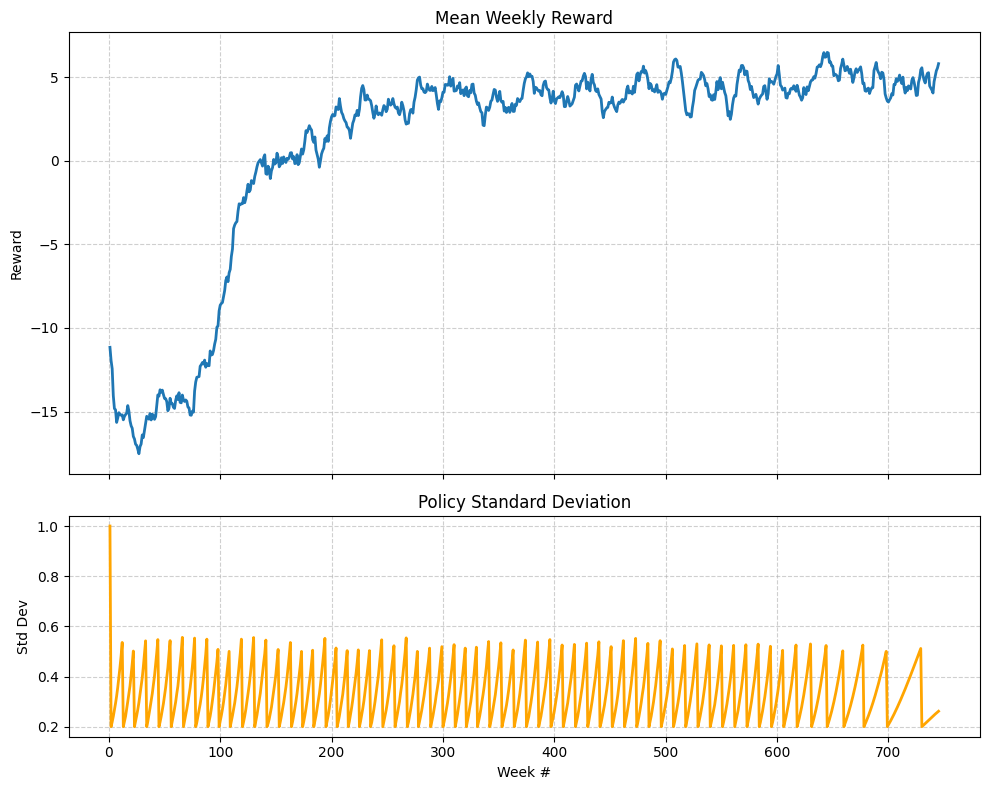

Training metrics saved to training_metrics_20250502_132815.png


In [49]:
# Plot and save training metrics
ts = datetime.now().strftime("%Y%m%d_%H%M%S")
img = f"training_metrics_{ts}.png"
if plot_training_metrics(callback, save_path=img, smoothing_window=10):
    print(f"Training metrics saved to {img}")

### Visualizing Inference

In [25]:
def visualize_continuous_inference(model, env, num_steps=1000, debug_battery=True):
    """
    Run the trained model in the environment for a continuous period without resets.
    
    Parameters:
    -----------
    model : Stable Baselines 3 model
        The trained PPO model
    env : gym.Env
        The microgrid environment
    num_steps : int
        Number of steps to run the simulation (can be longer than the standard episode length)
    debug_battery : bool
        Whether to print detailed battery SOC debugging information
    """
    # Set the model to evaluation mode (important for models with dropout layers)
    model.set_env(env)  # Ensure the environment is properly set
    model.policy.eval()  # Set the policy to evaluation mode
    
    # Data collectors
    observations = []
    actions = []
    rewards = []
    info_history = []
    timestamps = []
    day_boundaries = []
    battery_soc_changes = []  # Track SOC changes
    raw_battery_powers = []   # Track raw battery power commands
    actual_battery_powers = [] # Track actual battery power after constraints
    energy_changes = []       # Track energy changes to battery
    
    current_day = None
    
    # Initial reset to start at a random point
    obs, _ = env.reset()
    initial_soc = env.battery_soc
    
    print(f"Starting continuous inference for {num_steps} steps...")
    print(f"Initial battery SOC: {initial_soc:.4f}")
    
    for i in range(num_steps):
        # Get action from the model
        action, _states = model.predict(obs, deterministic=True)
        
        # Store raw battery power command (before any constraints are applied)
        raw_battery_power = action[0] * env.max_battery_discharge_rate
        raw_battery_powers.append(raw_battery_power)
        
        # Keep track of SOC before step
        soc_before = env.battery_soc
        
        # Take step in environment
        next_obs, reward, terminated, truncated, info = env.step(action)
        
        # Calculate SOC change
        soc_after = env.battery_soc
        soc_change = soc_after - soc_before
        battery_soc_changes.append(soc_change)
        
        # Store actual battery power used
        if 'battery_power' in info:
            actual_battery_powers.append(info['battery_power'])
        else:
            # If not available in info, calculate from SOC change
            # This is approximate and may not match the actual implementation
            time_factor = 5/60  # 5 min in hours
            capacity_factor = env.battery_capacity  # Battery capacity in kWh
            if soc_change > 0:  # Charging
                est_power = soc_change * capacity_factor / time_factor * env.battery_charging_efficiency
            else:  # Discharging
                est_power = soc_change * capacity_factor / time_factor / env.battery_discharging_efficiency
            actual_battery_powers.append(est_power)
            
        # Calculate energy change (kWh)
        energy_change = soc_change * env.battery_capacity
        energy_changes.append(energy_change)
            
        # Print detailed battery information if debug_battery is True
        if debug_battery and (i % 10 == 0 or abs(soc_change) > 0.05):
            print(f"Step {i}:")
            print(f"  Battery SOC: {soc_before:.4f} → {soc_after:.4f} (Δ: {soc_change:.4f})")
            print(f"  Battery action: {action[0]:.4f}, Raw power command: {raw_battery_power:.2f} kW")
            print(f"  Actual battery power: {actual_battery_powers[-1]:.2f} kW")
            print(f"  Energy change: {energy_change:.2f} kWh")
            if soc_after >= 0.999:
                print(f"  ALERT: Battery SOC at or near maximum (1.0)")
            if soc_after <= 0.201:
                print(f"  ALERT: Battery SOC at or near minimum (0.2)")
        
        # Store data
        observations.append(obs)
        actions.append(action)
        rewards.append(reward)
        info_history.append(info)
        
        # Record timestamp
        idx = env.start_idx + env.current_step - 1
        if idx >= 0 and idx < len(env.data):
            timestamp = env.data.index[idx]
            timestamps.append(timestamp)
            
            # Track day boundaries for visualization
            if current_day is None:
                current_day = timestamp.date()
            elif timestamp.date() != current_day:
                day_boundaries.append(i)
                current_day = timestamp.date()
                # Print daily summary
                if debug_battery:
                    print(f"\n==== New Day: {current_day} ====")
                    print(f"  Current Battery SOC: {soc_after:.4f}\n")
        else:
            timestamps.append(None)
        
        # CRITICAL CHANGE: Even if the environment signals done, we continue without resetting
        # This creates a continuous run across multiple days
        if terminated or truncated:
            # Instead of resetting, we manually advance the environment's internal counter
            env.start_idx += env.episode_length
            env.current_step = 0
            
            # We only reset the battery SOC if it was fully discharged (below 20%)
            # This creates a more realistic continuous scenario
            if env.battery_soc < env.min_battery_soc:
                soc_before_fix = env.battery_soc
                env.battery_soc = env.min_battery_soc
                if debug_battery:
                    print(f"  BATTERY RESET: SOC below minimum threshold, resetting from {soc_before_fix:.4f} to {env.battery_soc:.4f}")
            
            if debug_battery:
                print(f"Episode boundary at step {i}, continuing without full reset")
        
        # Update observation for next step
        obs = next_obs
    
    # Print summary statistics about battery behavior
    if debug_battery:
        print("\n===== BATTERY ANALYSIS SUMMARY =====")
        soc_changes = np.array(battery_soc_changes)
        powers = np.array(actual_battery_powers)
        
        print(f"SOC changes: min={soc_changes.min():.4f}, max={soc_changes.max():.4f}, mean={soc_changes.mean():.4f}")
        print(f"Actual battery powers: min={powers.min():.2f}kW, max={powers.max():.2f}kW, mean={powers.mean():.2f}kW")
        
        charging_steps = sum(1 for change in soc_changes if change > 0.001)
        discharging_steps = sum(1 for change in soc_changes if change < -0.001)
        static_steps = num_steps - charging_steps - discharging_steps
        
        print(f"Battery activity:")
        print(f"  Charging: {charging_steps} steps ({charging_steps/num_steps*100:.1f}%)")
        print(f"  Discharging: {discharging_steps} steps ({discharging_steps/num_steps*100:.1f}%)")
        print(f"  Static: {static_steps} steps ({static_steps/num_steps*100:.1f}%)")
        
        high_soc_steps = sum(1 for info in info_history if info['battery_soc'] > 0.95)
        print(f"Time spent at high SOC (>95%): {high_soc_steps} steps ({high_soc_steps/num_steps*100:.1f}%)")
    
    # Convert to numpy arrays for easier handling
    observations = np.array(observations)
    actions = np.array(actions)
    rewards = np.array(rewards)
    info_df = pd.DataFrame(info_history)

    # Add battery power analysis to info_df
    info_df['battery_soc_change'] = battery_soc_changes
    info_df['raw_battery_power'] = raw_battery_powers
    info_df['actual_battery_power'] = actual_battery_powers
    info_df['energy_change'] = energy_changes

    # Consistent figsize for all subplots
    consistent_figsize = (14, 6)

    # Plot 1: Actions taken by the agent
    fig, axes = plt.subplots(4, 1, figsize=(consistent_figsize[0], consistent_figsize[1] * 2), sharex=True)
    action_names = [
        'Battery Power (-1=discharge, 1=charge)',
        'Fuel Cell Power (0-1)',
        'Generator Power (0-1)',
        'Island Mode (0=grid, 1=island)'
    ]
    
    for i, (ax, name) in enumerate(zip(axes, action_names)):
        ax.plot(range(len(actions)), actions[:, i], 'b-')
        ax.set_title(name)
        ax.grid(True, alpha=0.3)
        
        # Add day boundary lines
        for boundary in day_boundaries:
            ax.axvline(x=boundary, color='r', linestyle='--', alpha=0.5)
        
        if i == 3:  # Island mode plot
            ax.set_yticks([0, 0.5, 1])
            ax.set_yticklabels(['Grid Connected', 'Threshold', 'Island Mode'])
    
    # Plot 2: Battery State and Renewable Usage
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(consistent_figsize[0], consistent_figsize[1] * 1.5), sharex=True)
    
    # Battery SOC plot
    ax1.plot(range(len(info_df)), info_df['battery_soc'] * 100)
    ax1.set_title('Battery State of Charge During Continuous Operation (%)')
    ax1.set_ylabel('SOC (%)')
    ax1.axhline(y=env.min_battery_soc * 100, color='r', linestyle='--', 
                label=f'Min SOC ({env.min_battery_soc * 100}%)')
                
    # Add target SOC range indicators
    ax1.axhspan(30, 70, alpha=0.2, color='green', label='Target SOC Range')
    ax1.axhline(y=50, color='g', linestyle='-.', alpha=0.7,
                label=f'Optimal SOC (50%)')
    
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # Add day boundary markers
    for boundary in day_boundaries:
        ax1.axvline(x=boundary, color='r', linestyle='--', alpha=0.5)
    
    # Battery Power Commands vs Actual Power
    ax2.plot(range(len(info_df)), info_df['raw_battery_power'], 'b-', label='Battery Command')
    ax2.plot(range(len(info_df)), info_df['actual_battery_power'], 'r-', label='Actual Battery Power')
    ax2.set_title('Battery Power Commands vs Actual Power (kW)')
    ax2.set_ylabel('Power (kW)')
    ax2.axhline(y=0, color='black', linewidth=0.5)
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    # Battery SOC Change per Step
    ax3.plot(range(len(info_df)), info_df['battery_soc_change'] * 100, 'g-')
    ax3.set_title('Battery SOC Change per Step (%)')
    ax3.set_ylabel('SOC Change (%)')
    ax3.set_xlabel('Simulation Step')
    ax3.axhline(y=0, color='black', linewidth=0.5)
    ax3.grid(True, alpha=0.3)
    
    fig.suptitle('Battery Metrics During Continuous Operation', fontsize=16)
    plt.tight_layout()
    plt.show()
    plt.close(fig)
    
    # Plot 3: Renewable Energy Usage
    if 'renewable_usage' in info_df.columns:
        plt.figure(figsize=(consistent_figsize[0], consistent_figsize[1]))
        plt.plot(range(len(info_df)), info_df['renewable_usage'] * 100)
        plt.title('Renewable Energy Usage (%)')
        plt.ylabel('Renewable Usage (%)')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    
    # Original plots continue below (adjusted as needed)
    # Plot 4: Power Sources
    plt.figure(figsize=(consistent_figsize[0], consistent_figsize[1]))
    
    # Get power information directly from info_df
    solar_power = np.array(info_df['solar_power'])
    wind_power = np.array(info_df['wind_power'])
    generator_power = np.array(info_df['generator_power'])
    fuel_cell_power = np.array(info_df['fuel_cell_power'])
    grid_power = np.array(info_df['grid_power'])
    
    # Separate grid import/export
    grid_import = np.maximum(0, grid_power)
    grid_export = -np.minimum(0, grid_power)
    
    # Plot power sources
    plt.plot(range(len(info_df)), solar_power, 'gold', label="Solar PV", linewidth=2)
    plt.plot(range(len(info_df)), wind_power, 'cyan', label="Wind", linewidth=2)
    plt.plot(range(len(info_df)), generator_power, 'darkorange', label="Generator", linewidth=2)
    plt.plot(range(len(info_df)), fuel_cell_power, 'limegreen', label="Fuel Cell", linewidth=2)
    plt.plot(range(len(info_df)), info_df['battery_discharge'], 'dodgerblue', label="Battery Discharge", linewidth=2)
    plt.plot(range(len(info_df)), grid_import, 'gray', label="Grid Import", linewidth=2)
    plt.plot(range(len(info_df)), -grid_export, 'r--', label="Grid Export", linewidth=2)
    
    # Zero line
    plt.axhline(0, color='black', linewidth=0.5)
    
    # Add day boundaries
    for boundary in day_boundaries:
        plt.axvline(x=boundary, color='r', linestyle='--', alpha=0.5)
    
    plt.title('Power Sources During Continuous Operation', fontsize=16)
    plt.ylabel('Power (kW)')
    plt.xlabel('Simulation Step')
    plt.grid(True, alpha=0.3)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()
    
    # Plot 5: Rewards
    fig, ax = plt.subplots(figsize=(consistent_figsize[0], consistent_figsize[1]))
    ax.plot(range(len(rewards)), rewards)
    ax.set_title('Reward During Continuous Operation')
    ax.set_ylabel('Reward')
    ax.set_xlabel('Simulation Step')
    ax.grid(True, alpha=0.3)
    
    # Add day boundaries
    for boundary in day_boundaries:
        ax.axvline(x=boundary, color='r', linestyle='--', alpha=0.5)
    
    # Add cumulative rewards
    cumulative_rewards = np.cumsum(rewards)
    ax2 = ax.twinx()
    ax2.plot(range(len(cumulative_rewards)), cumulative_rewards, 'g--', alpha=0.7)
    ax2.set_ylabel('Cumulative Reward', color='g')
    
    plt.tight_layout()
    plt.show()
    plt.close(fig)
    
    # Plot 6: Load Management (Updated for Unmet Load)
    fig, ax = plt.subplots(figsize=(consistent_figsize[0], consistent_figsize[1] * 1.5))
    
    critical = info_df['critical_load']
    essential = info_df['essential_load']
    non_critical = info_df['non_critical_load']
    
    # Create stacked plot of load types
    ax.stackplot(range(len(info_df)), critical, essential, non_critical, 
                 labels=['Critical', 'Essential', 'Non-Critical'], 
                 colors=['#ff6666', '#ffcc66', '#66b3ff'], alpha=0.7)
    
    # Plot unmet loads if they exist
    if info_df['unmet_critical_load'].sum() > 0 or info_df['unmet_essential_load'].sum() > 0:
        ax.plot(range(len(info_df)), info_df['unmet_critical_load'], 'ro--', 
                label='Unmet Critical Load', markersize=4, markevery=50, linewidth=1.5)
        ax.plot(range(len(info_df)), info_df['unmet_essential_load'], 'mo--', 
                label='Unmet Essential Load', markersize=4, markevery=50, linewidth=1.5)
    
    # Add combined legend
    ax.legend(loc='upper left')
    
    # Add day boundaries
    for boundary in day_boundaries:
        ax.axvline(x=boundary, color='r', linestyle='--', alpha=0.5)
    
    ax.set_ylabel('Power (kW)')
    ax.set_xlabel('Simulation Step')
    ax.set_title('Load Management During Continuous Operation', fontsize=16)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return info_df  # Return the dataframe with all the information for further analysis

In [23]:
# Load a model from a path, for visualizing if necessary
def zip_and_load_model(model_dir, env):
    # Create a temporary directory and zip file
    temp_dir = tempfile.mkdtemp()
    temp_zip_path = os.path.join(temp_dir, "model.zip")
    
    # Zip the contents of the model directory
    with zipfile.ZipFile(temp_zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, _, files in os.walk(model_dir):
            for file in files:
                file_path = os.path.join(root, file)
                # Calculate the relative path to maintain directory structure
                rel_path = os.path.relpath(file_path, model_dir)
                zipf.write(file_path, rel_path)
    
    print(f"Created temporary zip at: {temp_zip_path}")
    
    try:
        # Load the model from the temporary zip
        model = PPO.load(temp_zip_path, env=env)
        print("Successfully loaded model")
        return model
    finally:
        # Clean up the temporary directory
        shutil.rmtree(temp_dir)


# UPDATE DIRECTORY BASED ON WHERE TO LOAD MODEL FROM
model_dir = "/kaggle/input/ppo_model_2025-05-02_13-28-15/other/default/1"
model = zip_and_load_model(model_dir, env)

Created temporary zip at: /tmp/tmptc4kx9zw/model.zip
Successfully loaded model


Starting continuous inference for 5760 steps...
Initial battery SOC: 0.5292

step 288: battery state-of-charge (soc): 0.5419
  battery action: 0.0012, actual battery power (kw): 0.0364
  energy change (kwh): -0.0032, new soc: 0.5419
  generator output (kw): 240.00, fuel cell output (kw): 36.72
  island mode: True, renewable ratio: 0.0000
  total load (kw): 490.03, total generation (kw): 301.19
  reward breakdown:
    + renewable energy reward: 244.70
    + battery target soc reward: 11.77
    + fuel efficiency reward: 2.70
    + export revenue (to grid): 0.00
    - grid import cost: 0.00
    - battery violation penalty: 0.00
    - low soc penalty: 0.00
    - high soc penalty: 0.00
    - fuel cost: -138.36
    - unmet load penalty: -188.00
    - grid connection penalty: -0.00
    => total reward: -0.0067

step 288: battery state-of-charge (soc): 0.5504
  battery action: -0.0004, actual battery power (kw): -0.0126
  energy change (kwh): 0.0010, new soc: 0.5504
  generator output (kw): 24

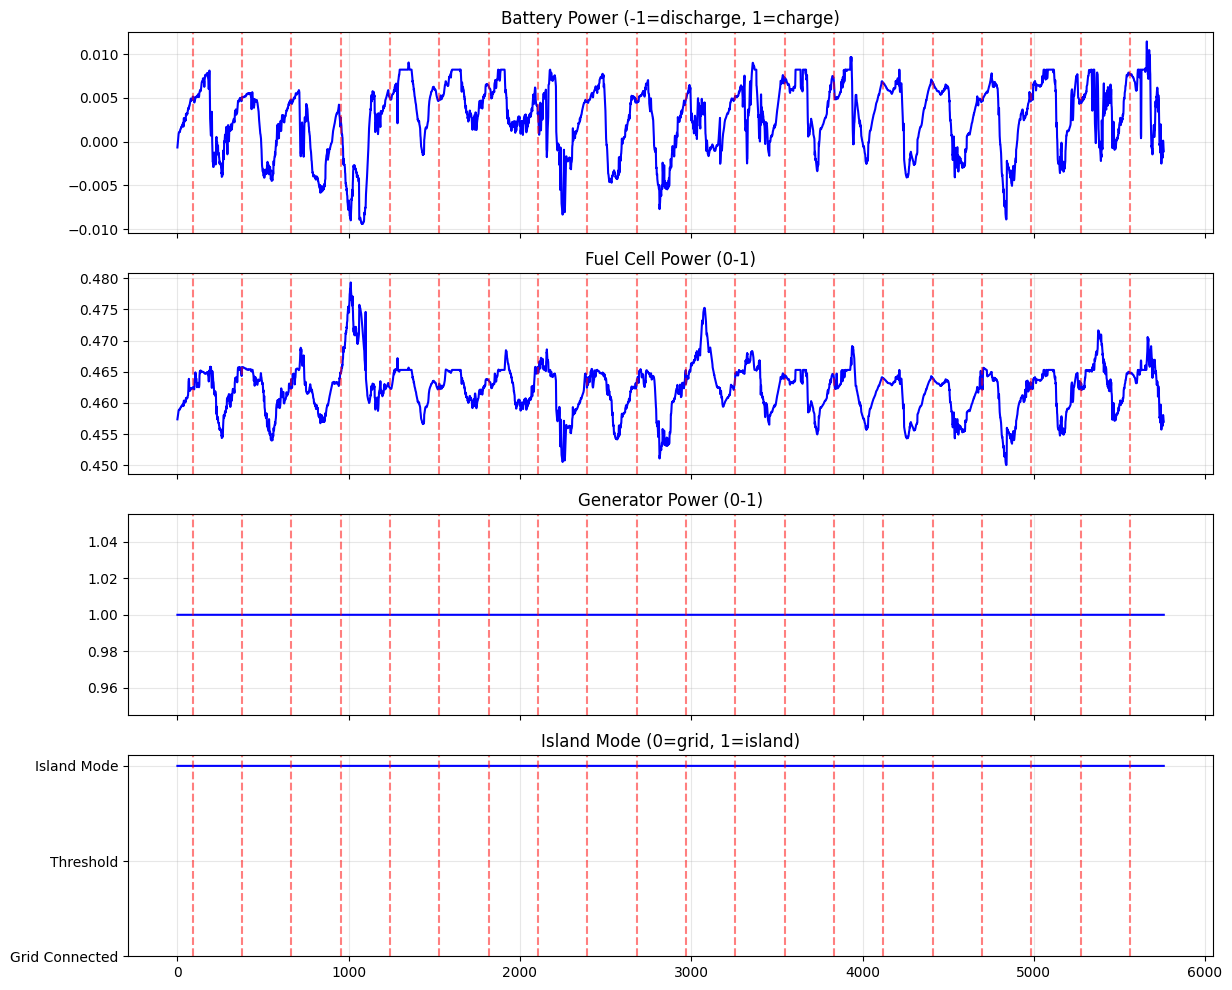

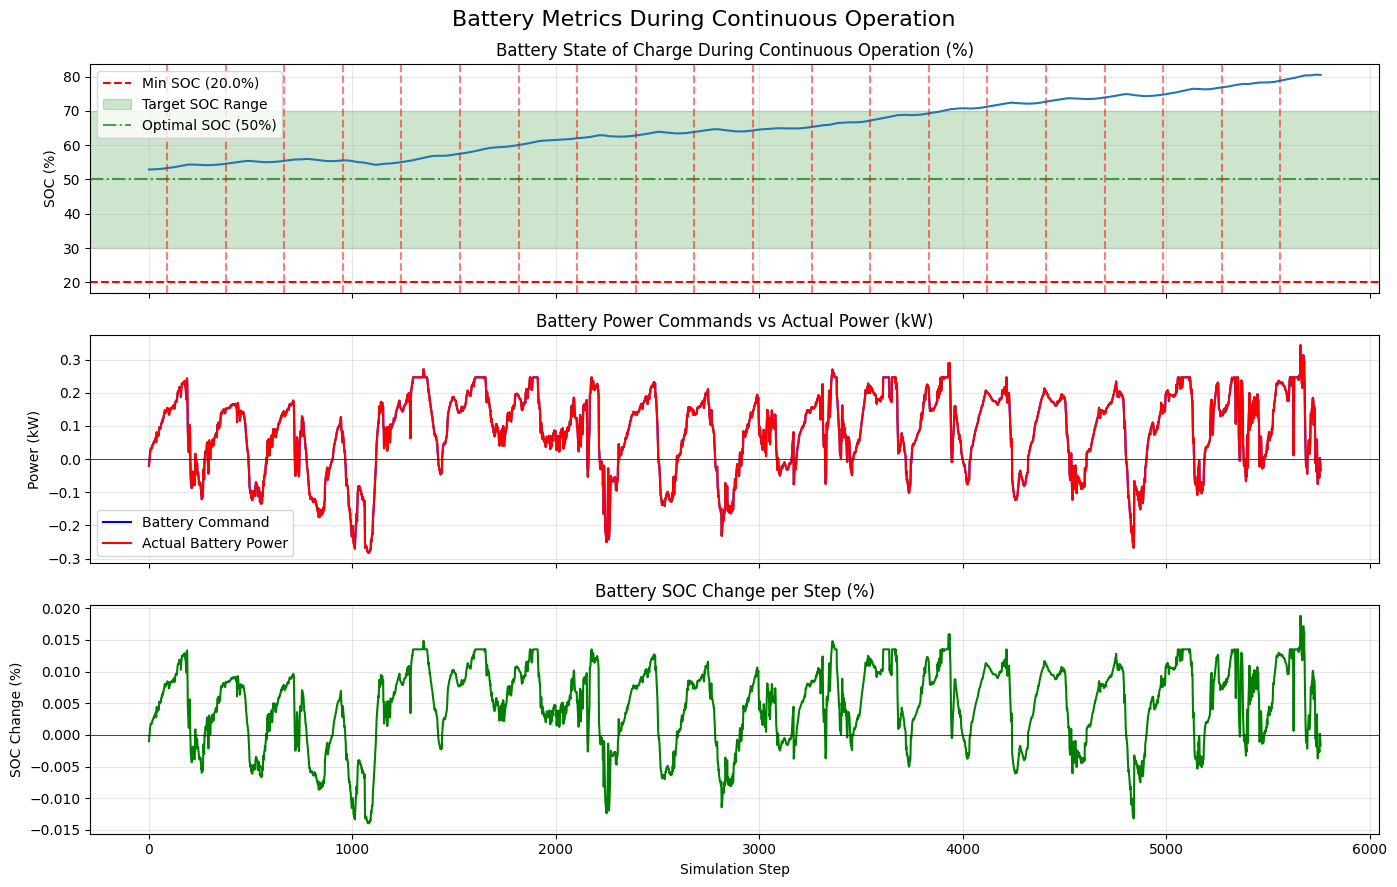

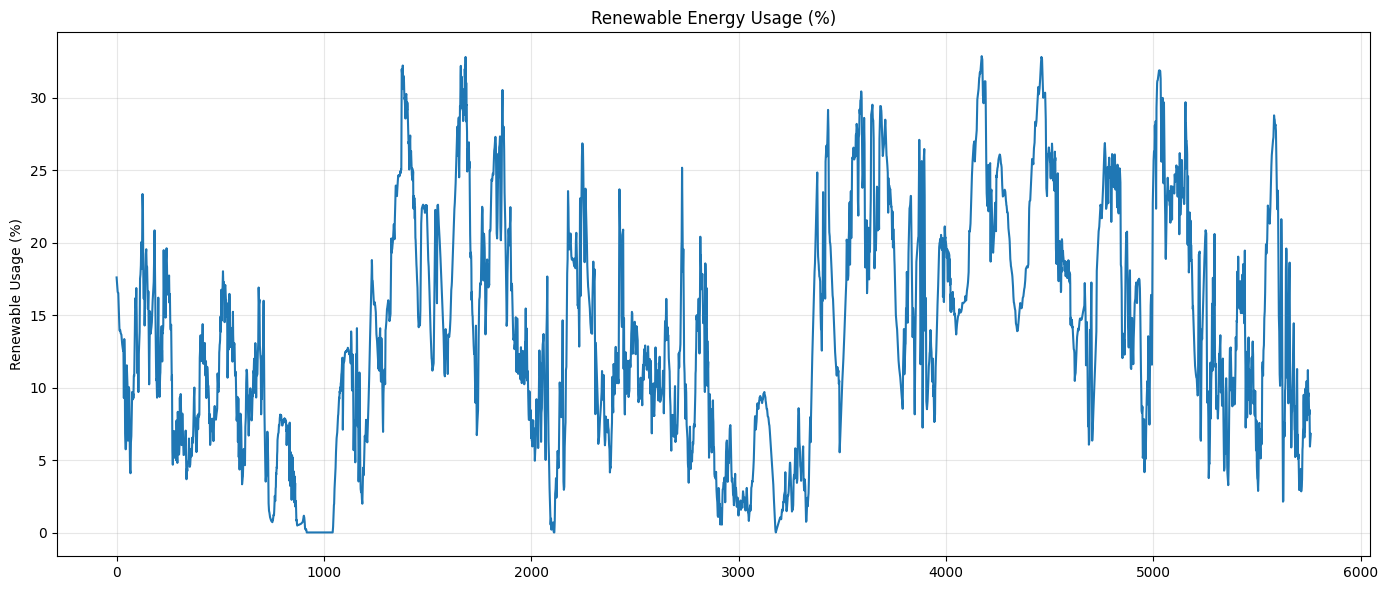

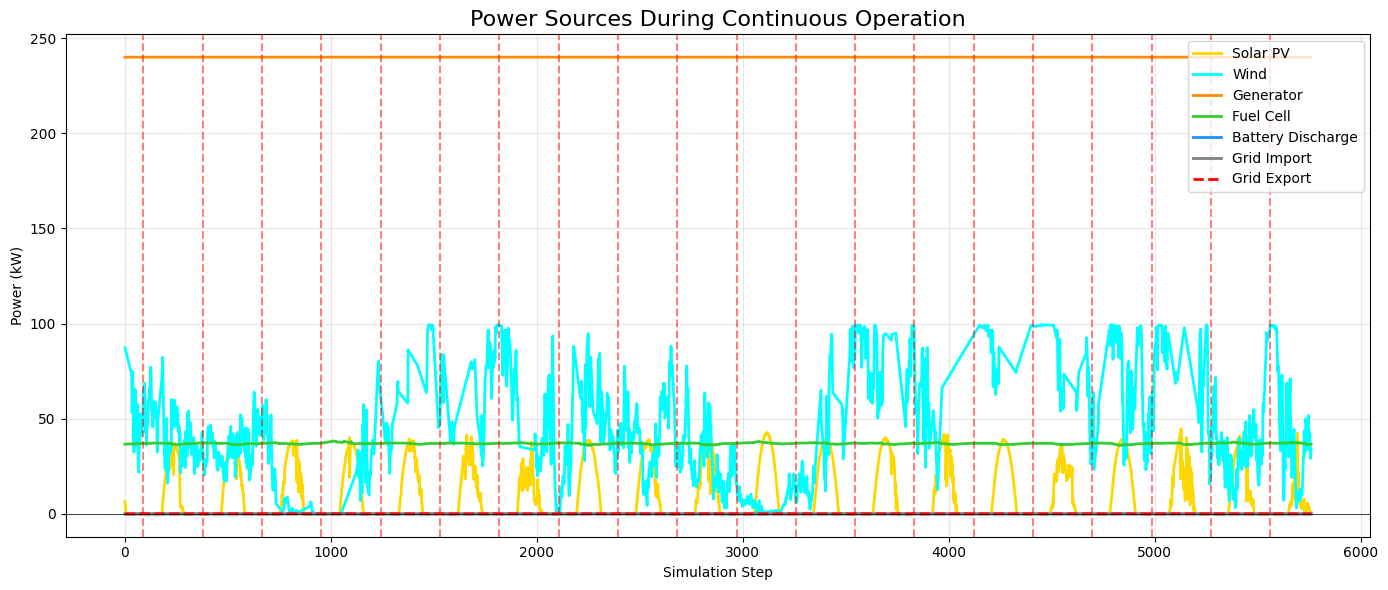

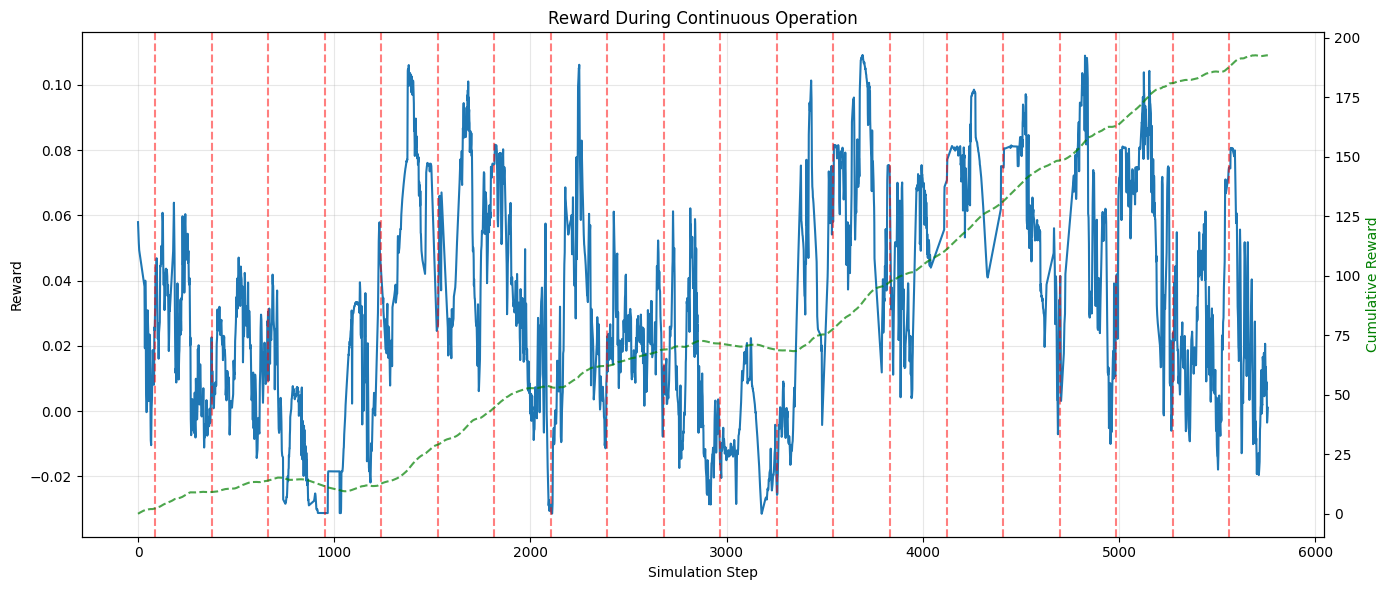

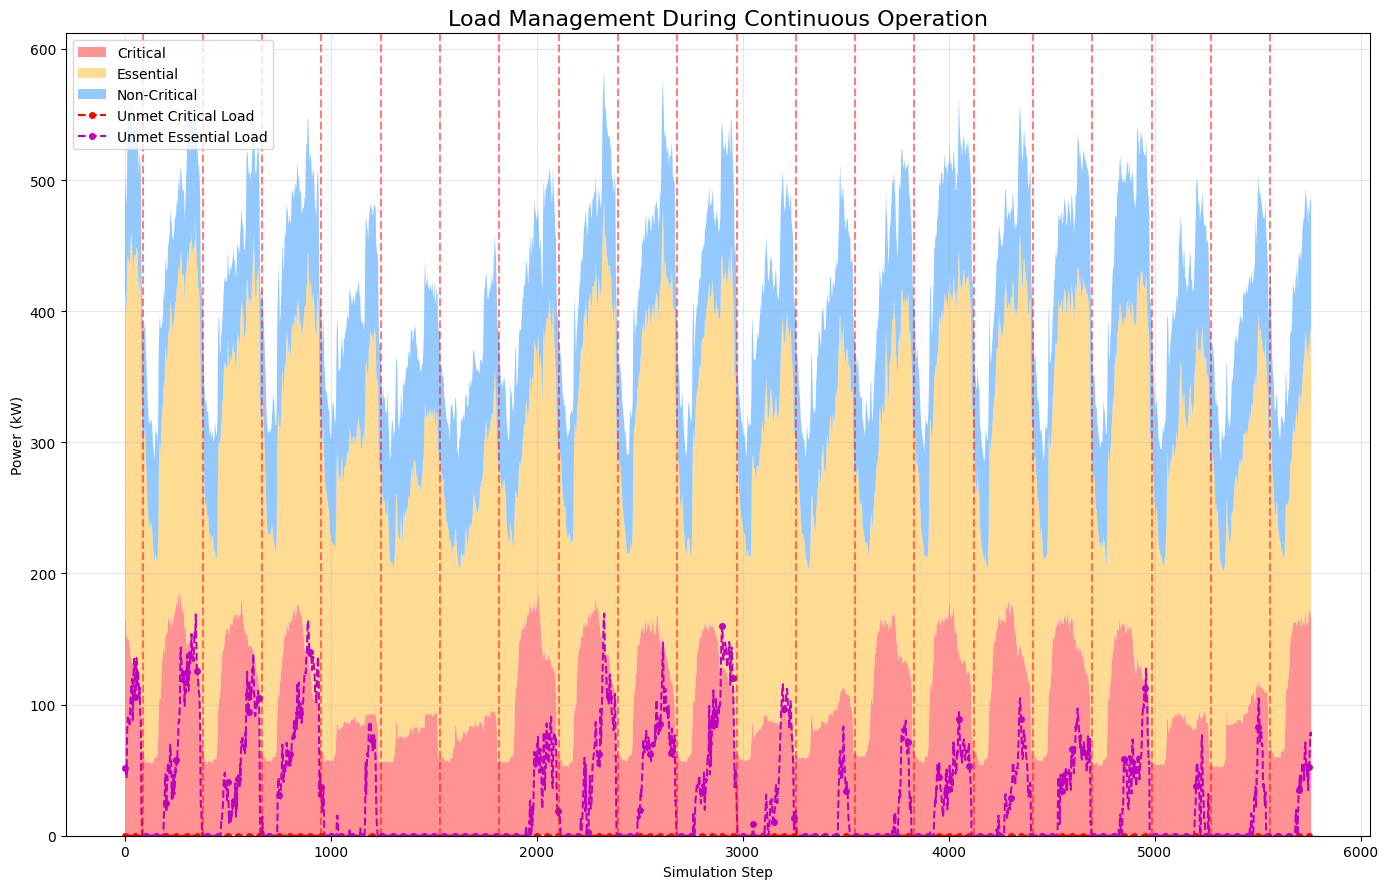

In [26]:
result_df = visualize_continuous_inference(model, env, num_steps=288 * 20, debug_battery=False)